# SCR Analysis: Acquisition, Extinction, And Reinstatement

This notebook analyzes trial-wise SCR for acquisition, extinction, and reinstatement using the agreed scoring rule:

- Raw SCR amplitude is `phaBase2Peak`.
- Negative responses and responses below `0.02 uS` are coded as zero.
- The analysis score is the square-root transformed thresholded amplitude.
- Primary analyses retain all participants.
- SCR-defined responders and learners are sensitivity subsets only.

Learner definitions are matched to `identify_fear_learning_subjects_scr.ipynb`:

- Physiological SCR responder: at least two acquisition CS+ trials with raw SCR >= `0.05 uS`.
- Simple acquisition differential learner: physiological responder with mean CS+ > CS- across acquisition.
- Habituation-adjusted learner: physiological responder with a positive CS+ beta from `sqrtSCR ~ CSplus + Trial_Z`.
- Late-phase sensitivity learner: late CS+ > CS- and late discrimination greater than early discrimination.

The statistical sections report full-sample effects and repeat the same tests in learner sensitivity subsets. Each phase also includes SAD-vs-HC group comparisons.


## 1. Setup


In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_rows", 240)
pd.set_option("display.max_columns", 220)
warnings.filterwarnings("ignore", category=RuntimeWarning)

DATA_DIR = Path("/Users/xiaoqianxiao/projects/NARSAD/EDR")
ACQ_PATH = DATA_DIR / "peak_stats_table-phase1.csv"
PHASE23_PATH = DATA_DIR / "peak_stats_table-phase2.3.csv"
META_PATH = Path("/Users/xiaoqianxiao/projects/NARSAD/MRI/source_data/behav/drug_order.csv")
OUT_DIR = Path("scr_analysis_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_COL = "phaBase2Peak"
THRESH_COL = "phaBase2Peak_thresholded_0p02"
SCORE_COL = "sqrt_phaBase2Peak"
BAD_COL = "bad"
RESPONSE_THRESHOLD_RAW = 0.02
PHYSIO_RESPONDER_THRESHOLD_RAW = 0.05
PHYSIO_RESPONDER_MIN_CSPLUS_TRIALS = 2
WINDOW_N = 4

CONDITION_ORDER = ["CS-", "CSS", "CSR"]
DOMAIN_ORDER = ["CS-", "CS+"]
PHASE_ORDER = ["Acquisition", "Extinction", "Reinstatement"]
GROUP_ORDER = ["HC", "SAD"]
ANALYSIS_SET_ORDER = [
    "All subjects",
    "Physiological responders",
    "Simple CS+ learners",
    "Habituation-adjusted CS+ learners",
    "Late-phase sensitivity CS+ learners",
]
CONTRAST_ORDER = ["CS+ - CS-", "CSS - CS-", "CSR - CS-"]

GROUP_PALETTE = {"HC": "#4C72B0", "SAD": "#C44E52"}
CONDITION_PALETTE = {"CS-": "#4C72B0", "CSS": "#C44E52", "CSR": "#DD8452", "CS+": "#8C564B"}
SET_PALETTE = {
    "All subjects": "#3B6EA8",
    "Physiological responders": "#6A51A3",
    "Simple CS+ learners": "#2F9E44",
    "Habituation-adjusted CS+ learners": "#C44E52",
    "Late-phase sensitivity CS+ learners": "#DD8452",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.25)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "Arial",
    "axes.linewidth": 1.1,
    "axes.edgecolor": "#333333",
    "axes.titleweight": "regular",
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

print("ACQ_PATH:", ACQ_PATH, "exists=", ACQ_PATH.exists())
print("PHASE23_PATH:", PHASE23_PATH, "exists=", PHASE23_PATH.exists())
print("META_PATH:", META_PATH, "exists=", META_PATH.exists())
print("OUT_DIR:", OUT_DIR.resolve())


def save_current_fig(name, dpi=300):
    path = FIG_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure ->", path)
    return path


def safe_percent(n, d):
    return 100 * n / d if d else np.nan


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def p_text(p):
    if pd.isna(p):
        return "p=NA"
    if p < 0.001:
        return "p<.001"
    return f"p={p:.3f}".replace("0.", ".")


def safe_mean(series):
    x = pd.to_numeric(pd.Series(series), errors="coerce").dropna()
    return float(x.mean()) if len(x) else np.nan


def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", color="#D0D0D0", linewidth=0.8)
    ax.grid(False, axis="x")
    return ax



ACQ_PATH: /Users/xiaoqianxiao/projects/NARSAD/EDR/peak_stats_table-phase1.csv exists= True
PHASE23_PATH: /Users/xiaoqianxiao/projects/NARSAD/EDR/peak_stats_table-phase2.3.csv exists= True
META_PATH: /Users/xiaoqianxiao/projects/NARSAD/MRI/source_data/behav/drug_order.csv exists= True
OUT_DIR: /Users/xiaoqianxiao/PycharmProjects/narsad_multivoxel/scr_analysis_outputs


## 2. Load, Score, And Annotate SCR


In [2]:
def load_metadata(path=META_PATH):
    if not path.exists():
        print(f"Metadata not found: {path}. Group comparisons will be unavailable.")
        return pd.DataFrame(columns=["Subject", "Group", "Drug"])
    meta = pd.read_csv(path)
    if "subject_id" not in meta.columns:
        raise ValueError(f"Metadata file {path} does not contain subject_id")
    meta = meta.copy()
    meta["Subject"] = meta["subject_id"].astype(str).str.strip()
    keep = [c for c in ["Subject", "Group", "Drug", "drug_condition", "Gender", "gender_code", "demo_age", "guess"] if c in meta.columns]
    meta = meta[keep].drop_duplicates("Subject")
    if "Group" in meta.columns:
        meta["Group"] = meta["Group"].astype(str).str.strip()
    if "Drug" in meta.columns:
        meta["Drug"] = meta["Drug"].astype(str).str.strip()
    return meta


def load_scr_file(path, phase_name=None):
    df = pd.read_csv(path)
    required = {"sid", "stTy", "stNum", RAW_COL}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    df = df.copy()
    df["Subject"] = df["sid"].astype(str).str.strip()
    df["stNum"] = pd.to_numeric(df["stNum"], errors="coerce")
    df[RAW_COL] = pd.to_numeric(df[RAW_COL], errors="coerce")
    if BAD_COL in df.columns:
        df[BAD_COL] = pd.to_numeric(df[BAD_COL], errors="coerce").fillna(0).astype(int)
        df = df[df[BAD_COL] == 0].copy()
    df["Condition"] = df["stTy"].replace({"CS+S": "CSS", "CS+R": "CSR", "CS-": "CS-"})
    df = df[df["Condition"].isin(CONDITION_ORDER)].copy()
    df["Domain"] = np.where(df["Condition"].isin(["CSS", "CSR"]), "CS+", "CS-")
    df[THRESH_COL] = np.where(df[RAW_COL] >= RESPONSE_THRESHOLD_RAW, df[RAW_COL], 0.0)
    df[SCORE_COL] = np.sqrt(df[THRESH_COL])
    if phase_name is not None:
        df["Phase"] = phase_name
    df = df.dropna(subset=["Subject", "stNum", "Condition", RAW_COL, THRESH_COL, SCORE_COL])
    return df

meta = load_metadata()
acq = load_scr_file(ACQ_PATH, phase_name="Acquisition")
phase23 = load_scr_file(PHASE23_PATH)
extinction = phase23[(phase23["stNum"] >= 1) & (phase23["stNum"] <= 24)].copy()
extinction["Phase"] = "Extinction"
reinstatement = phase23[(phase23["stNum"] >= 25) & (phase23["stNum"] <= 48)].copy()
reinstatement["Phase"] = "Reinstatement"

all_scr = pd.concat([acq, extinction, reinstatement], ignore_index=True)
if not meta.empty:
    all_scr = all_scr.merge(meta, on="Subject", how="left")
else:
    all_scr["Group"] = np.nan
    all_scr["Drug"] = np.nan

all_scr["Phase"] = pd.Categorical(all_scr["Phase"], categories=PHASE_ORDER, ordered=True)
all_scr["Condition"] = pd.Categorical(all_scr["Condition"], categories=CONDITION_ORDER, ordered=True)
all_scr["ConditionTrial"] = all_scr.groupby(["Subject", "Phase", "Condition"], observed=False).cumcount() + 1
all_scr["PhaseTrial"] = all_scr.groupby(["Subject", "Phase"], observed=False).cumcount() + 1
all_scr["Window"] = np.where(all_scr["ConditionTrial"] <= WINDOW_N, "Early", np.where(all_scr["ConditionTrial"] > 8 - WINDOW_N, "Late", "Middle"))
all_scr["Trial_Z"] = all_scr.groupby(["Subject", "Phase"], observed=False)["PhaseTrial"].transform(lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0)

print("Rows and subjects by phase")
display(all_scr.groupby("Phase", observed=False).agg(rows=("Subject", "size"), subjects=("Subject", "nunique")))
print("Trial count by phase and condition")
display(all_scr.groupby(["Phase", "Condition"], observed=False).size().unstack(fill_value=0))
print("Subjects by Group x Drug")
display(all_scr[["Subject", "Group", "Drug"]].drop_duplicates().groupby(["Group", "Drug"], dropna=False).size().rename("subjects").reset_index())
print("SCR distribution after scoring")
display(all_scr[[RAW_COL, THRESH_COL, SCORE_COL]].describe())


Rows and subjects by phase


,rows,subjects
Phase,,
Acquisition,2496,104
Extinction,2424,101
Reinstatement,2424,101


Trial count by phase and condition


Condition,CS-,CSS,CSR
Phase,,,
Acquisition,832,832,832
Extinction,808,808,808
Reinstatement,808,808,808


Subjects by Group x Drug


,Group,Drug,subjects
0,HC,Oxytocin,24
1,HC,Placebo,29
2,SAD,Oxytocin,28
3,SAD,Placebo,23


SCR distribution after scoring


,phaBase2Peak,phaBase2Peak_thresholded_0p02,sqrt_phaBase2Peak
count,7344.000000,7344.000000,7344.000000
mean,0.052029,0.048170,0.138113
std,0.121309,0.122652,0.170583
min,-0.026000,0.000000,0.000000
25%,0.012000,0.000000,0.000000
50%,0.021000,0.021000,0.144914
75%,0.035000,0.035000,0.187083
max,3.808000,3.808000,1.951410


## 3. Describe SCR And Diagnose Floor/Habituation


,Phase,Condition,N_trials,N_subjects,Raw_mean,Raw_median,Sqrt_mean,Sqrt_median,Percent_raw_below_0p02,Percent_raw_ge_0p05
0,Acquisition,CS-,832,104,0.049697,0.007,0.111493,0.000000,65.264423,21.033654
1,Acquisition,CSS,832,104,0.060542,0.004,0.130452,0.000000,63.581731,26.442308
2,Acquisition,CSR,832,104,0.059024,0.004,0.123565,0.000000,66.105769,24.759615
3,Extinction,CS-,808,101,0.038884,0.022,0.123844,0.148324,37.128713,10.519802
4,Extinction,CSS,808,101,0.038624,0.022,0.127201,0.148324,36.757426,11.138614
5,Extinction,CSR,808,101,0.035712,0.021,0.118600,0.144914,40.594059,11.014851
6,Reinstatement,CS-,808,101,0.058097,0.024,0.160993,0.154919,31.930693,19.306931
7,Reinstatement,CSS,808,101,0.062053,0.026,0.172495,0.161245,28.465347,22.400990
8,Reinstatement,CSR,808,101,0.065235,0.025,0.175821,0.158114,28.341584,22.153465


Saved figure -> scr_analysis_outputs/figures/scr_description_mean_and_floor_by_phase.png


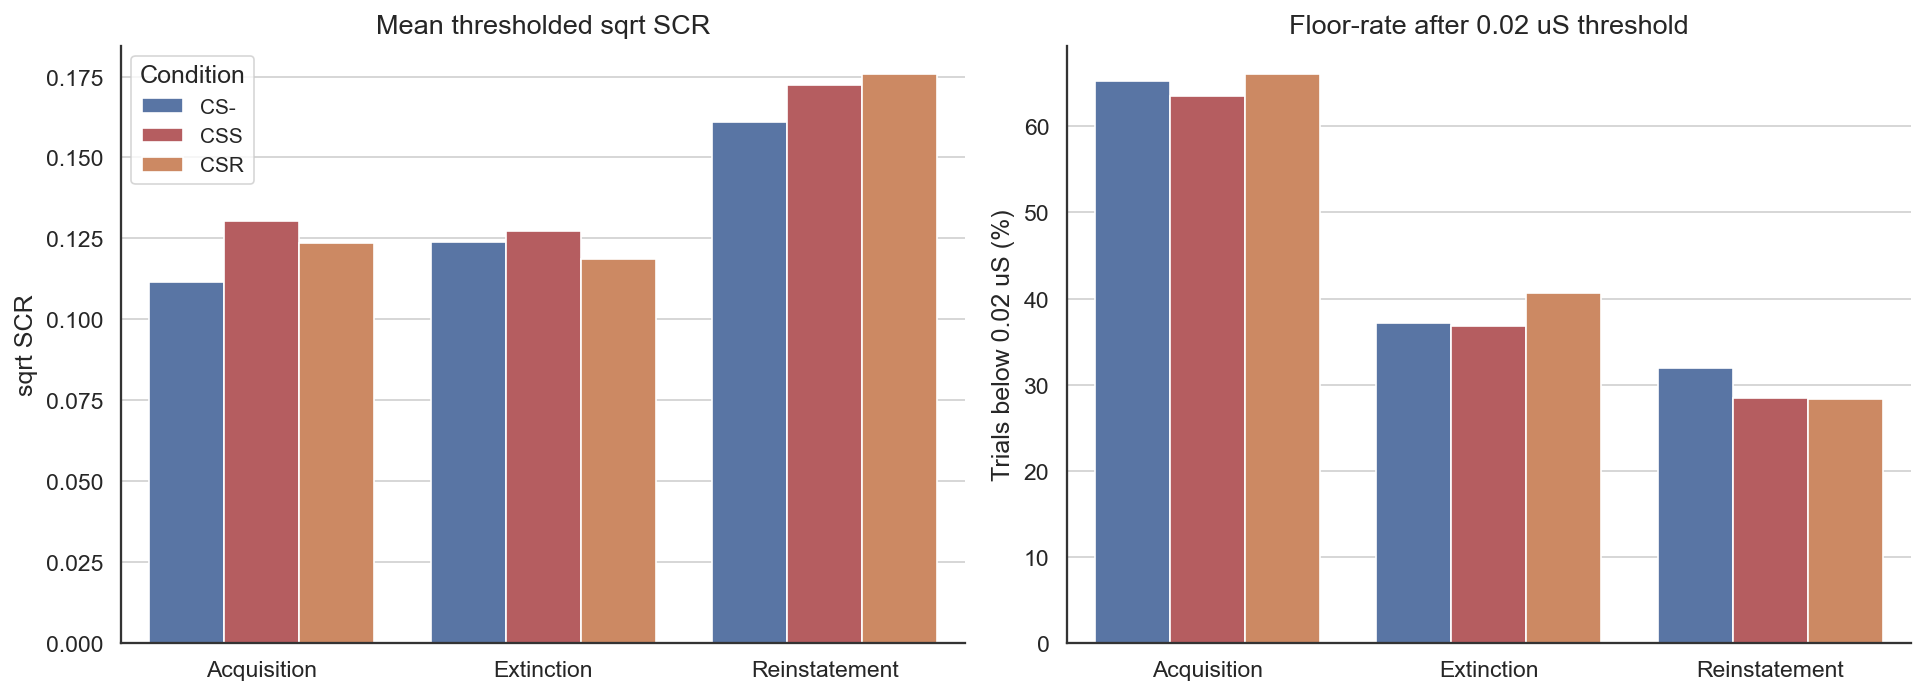

Acquisition habituation/floor paired statistics


,Condition,N,Early_sqrt_mean,Late_sqrt_mean,Late_minus_Early_sqrt,t_late_less_early,p_late_less_early,Early_floor_percent,Late_floor_percent,Late_minus_Early_floor_percent,t_floor_late_greater_early,p_floor_late_greater_early
0,CS-,104,0.160658,0.062327,-0.098331,-8.864665,1.227098e-14,52.884615,77.644231,24.759615,7.838867,2.168616e-12
1,CSS,104,0.192241,0.068664,-0.123577,-8.404385,1.267292e-13,48.798077,78.365385,29.567308,9.085195,3.988367e-15
2,CSR,104,0.171007,0.076123,-0.094884,-7.402751,1.879937e-11,55.769231,76.442308,20.673077,7.315147,2.889729e-11


/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_34332/4158527903.py:97: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


Saved figure -> scr_analysis_outputs/figures/scr_acquisition_habituation_floor_early_late_bars.png


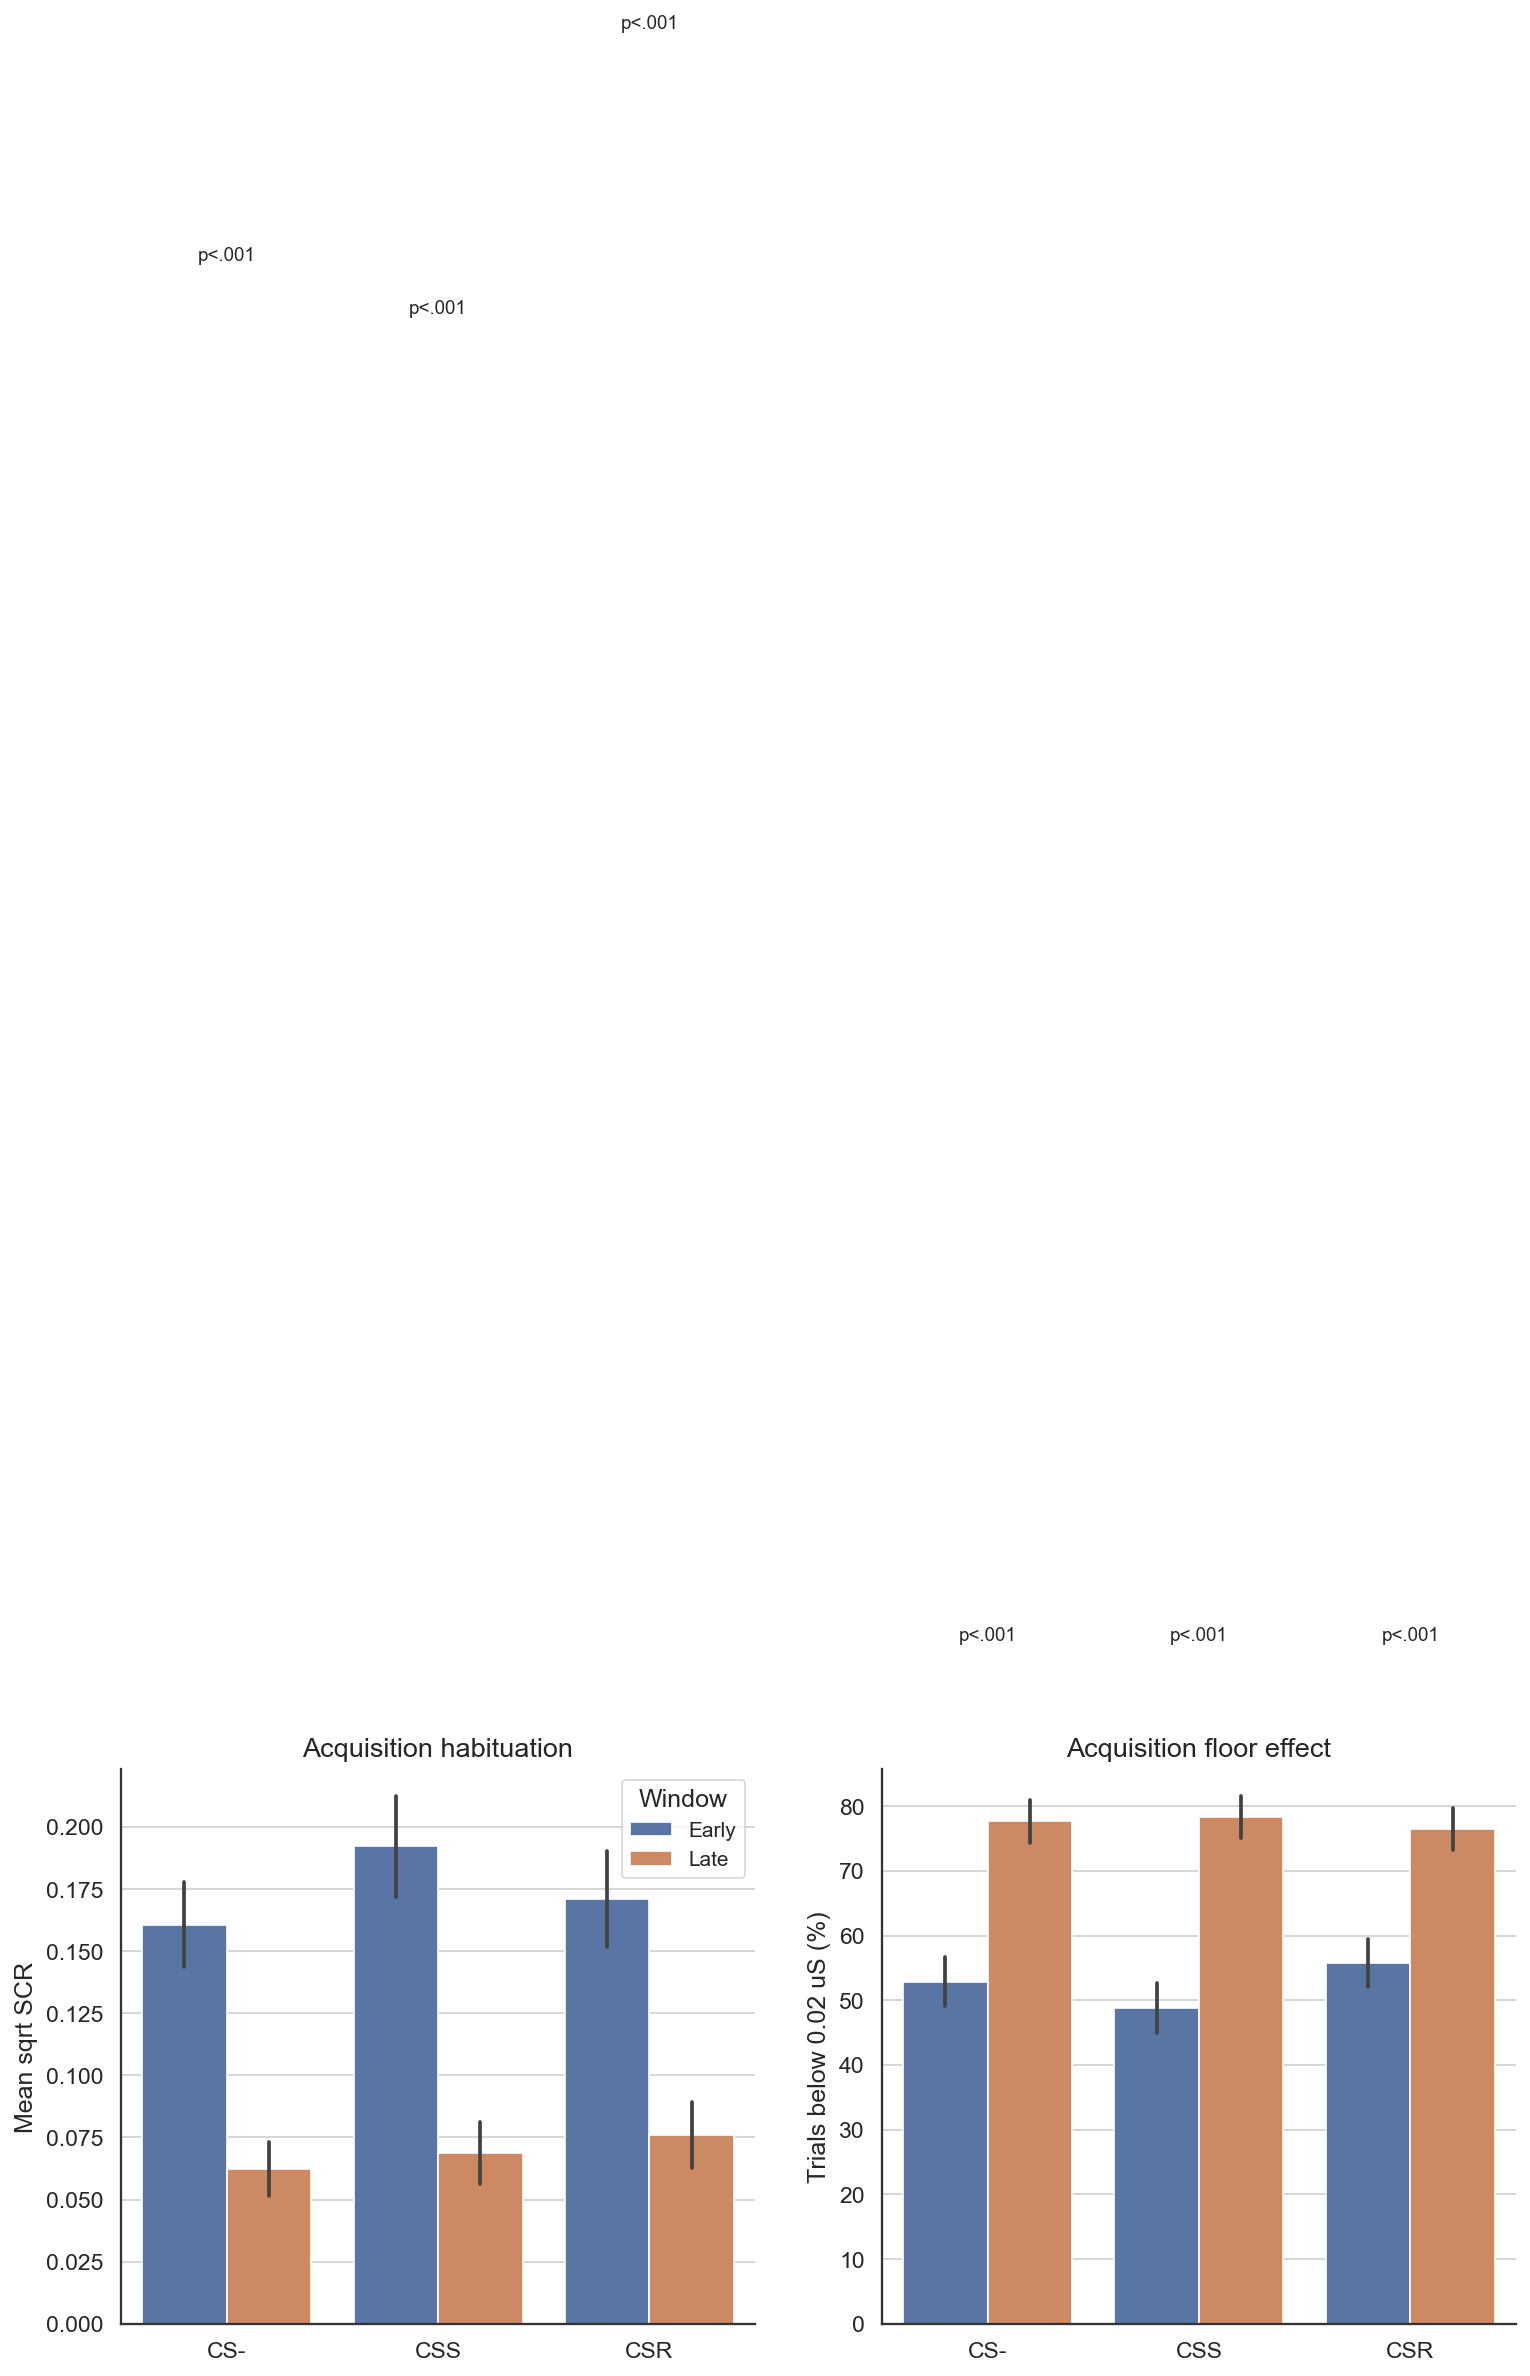

In [3]:
floor_rows = []
for phase in PHASE_ORDER:
    sub = all_scr[all_scr["Phase"] == phase]
    for condition in CONDITION_ORDER:
        g = sub[sub["Condition"] == condition]
        floor_rows.append({
            "Phase": phase,
            "Condition": condition,
            "N_trials": int(len(g)),
            "N_subjects": int(g["Subject"].nunique()),
            "Raw_mean": float(g[RAW_COL].mean()),
            "Raw_median": float(g[RAW_COL].median()),
            "Sqrt_mean": float(g[SCORE_COL].mean()),
            "Sqrt_median": float(g[SCORE_COL].median()),
            "Percent_raw_below_0p02": float((g[RAW_COL] < RESPONSE_THRESHOLD_RAW).mean() * 100),
            "Percent_raw_ge_0p05": float((g[RAW_COL] >= PHYSIO_RESPONDER_THRESHOLD_RAW).mean() * 100),
        })
floor_summary = pd.DataFrame(floor_rows)
display(floor_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(data=floor_summary, x="Phase", y="Sqrt_mean", hue="Condition", order=PHASE_ORDER, hue_order=CONDITION_ORDER, palette=CONDITION_PALETTE, errorbar=None, ax=axes[0])
axes[0].set_title("Mean thresholded sqrt SCR")
axes[0].set_ylabel("sqrt SCR")
axes[0].set_xlabel("")
clean_axis(axes[0])
sns.barplot(data=floor_summary, x="Phase", y="Percent_raw_below_0p02", hue="Condition", order=PHASE_ORDER, hue_order=CONDITION_ORDER, palette=CONDITION_PALETTE, errorbar=None, ax=axes[1])
axes[1].set_title("Floor-rate after 0.02 uS threshold")
axes[1].set_ylabel("Trials below 0.02 uS (%)")
axes[1].set_xlabel("")
clean_axis(axes[1])
axes[1].legend_.remove()
plt.tight_layout()
save_current_fig("scr_description_mean_and_floor_by_phase.png")
plt.show()

# Acquisition-specific habituation evidence: early and late bars, not just difference.
hab_rows = []
for condition in CONDITION_ORDER:
    for subject, g in all_scr[(all_scr["Phase"] == "Acquisition") & (all_scr["Condition"] == condition)].groupby("Subject"):
        for window in ["Early", "Late"]:
            gw = g[g["Window"] == window]
            hab_rows.append({
                "Subject": subject,
                "Group": gw["Group"].dropna().iloc[0] if gw["Group"].notna().any() else np.nan,
                "Condition": condition,
                "Window": window,
                "Mean_sqrtSCR": safe_mean(gw[SCORE_COL]),
                "Floor_percent": float((gw[RAW_COL] < RESPONSE_THRESHOLD_RAW).mean() * 100) if len(gw) else np.nan,
            })
hab_df = pd.DataFrame(hab_rows)

hab_stats = []
for condition in CONDITION_ORDER:
    wide = hab_df[hab_df["Condition"] == condition].pivot(index="Subject", columns="Window", values="Mean_sqrtSCR").dropna()
    diff = wide["Late"] - wide["Early"]
    t = stats.ttest_rel(wide["Late"], wide["Early"], alternative="less") if len(diff) >= 2 else None
    wide_floor = hab_df[hab_df["Condition"] == condition].pivot(index="Subject", columns="Window", values="Floor_percent").dropna()
    fdiff = wide_floor["Late"] - wide_floor["Early"]
    ft = stats.ttest_rel(wide_floor["Late"], wide_floor["Early"], alternative="greater") if len(fdiff) >= 2 else None
    hab_stats.append({
        "Condition": condition,
        "N": len(diff),
        "Early_sqrt_mean": float(wide["Early"].mean()),
        "Late_sqrt_mean": float(wide["Late"].mean()),
        "Late_minus_Early_sqrt": float(diff.mean()),
        "t_late_less_early": float(t.statistic) if t is not None else np.nan,
        "p_late_less_early": float(t.pvalue) if t is not None else np.nan,
        "Early_floor_percent": float(wide_floor["Early"].mean()),
        "Late_floor_percent": float(wide_floor["Late"].mean()),
        "Late_minus_Early_floor_percent": float(fdiff.mean()),
        "t_floor_late_greater_early": float(ft.statistic) if ft is not None else np.nan,
        "p_floor_late_greater_early": float(ft.pvalue) if ft is not None else np.nan,
    })
habituation_stats = pd.DataFrame(hab_stats)
print("Acquisition habituation/floor paired statistics")
display(habituation_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.barplot(data=hab_df, x="Condition", y="Mean_sqrtSCR", hue="Window", order=CONDITION_ORDER, hue_order=["Early", "Late"], palette=["#4C72B0", "#DD8452"], errorbar="se", ax=axes[0])
axes[0].set_title("Acquisition habituation")
axes[0].set_ylabel("Mean sqrt SCR")
axes[0].set_xlabel("")
clean_axis(axes[0])
for idx, row in habituation_stats.iterrows():
    y = hab_df.loc[hab_df["Condition"] == row["Condition"], "Mean_sqrtSCR"].max() + 0.015
    axes[0].text(idx, y, p_text(row["p_late_less_early"]), ha="center", va="bottom", fontsize=9)
sns.barplot(data=hab_df, x="Condition", y="Floor_percent", hue="Window", order=CONDITION_ORDER, hue_order=["Early", "Late"], palette=["#4C72B0", "#DD8452"], errorbar="se", ax=axes[1])
axes[1].set_title("Acquisition floor effect")
axes[1].set_ylabel("Trials below 0.02 uS (%)")
axes[1].set_xlabel("")
clean_axis(axes[1])
axes[1].legend_.remove()
for idx, row in habituation_stats.iterrows():
    y = hab_df.loc[hab_df["Condition"] == row["Condition"], "Floor_percent"].max() + 5
    axes[1].text(idx, y, p_text(row["p_floor_late_greater_early"]), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save_current_fig("scr_acquisition_habituation_floor_early_late_bars.png")
plt.show()


## 4. Define Responders And Learners


Overall learner rates


,Definition,N,Total,Percent_of_total
0,Physiological SCR responder,59,104,56.730769
1,Simple acquisition differential: pooled CS+ > CS-,41,104,39.423077
2,Habituation-adjusted beta: pooled CS+ > CS-,32,104,30.769231
3,Late-phase sensitivity: pooled CS+,22,104,21.153846


Learner rates by Group


,Group,Definition,N,Total,Percent_of_total
0,HC,Physiological SCR responder,32,53,60.377358
1,HC,Simple acquisition differential: pooled CS+ > CS-,21,53,39.622642
2,HC,Habituation-adjusted beta: pooled CS+ > CS-,15,53,28.301887
3,HC,Late-phase sensitivity: pooled CS+,11,53,20.754717
4,SAD,Physiological SCR responder,27,51,52.941176
5,SAD,Simple acquisition differential: pooled CS+ > CS-,20,51,39.215686
6,SAD,Habituation-adjusted beta: pooled CS+ > CS-,17,51,33.333333
7,SAD,Late-phase sensitivity: pooled CS+,11,51,21.568627


Learner rates by Group x Drug


,Group,Drug,Definition,N,Total,Percent_of_total
0,HC,Oxytocin,Physiological SCR responder,13,24,54.166667
1,HC,Oxytocin,Simple acquisition differential: pooled CS+ > CS-,8,24,33.333333
2,HC,Oxytocin,Habituation-adjusted beta: pooled CS+ > CS-,5,24,20.833333
3,HC,Oxytocin,Late-phase sensitivity: pooled CS+,7,24,29.166667
4,HC,Placebo,Physiological SCR responder,19,29,65.517241
5,HC,Placebo,Simple acquisition differential: pooled CS+ > CS-,13,29,44.827586
6,HC,Placebo,Habituation-adjusted beta: pooled CS+ > CS-,10,29,34.482759
7,HC,Placebo,Late-phase sensitivity: pooled CS+,4,29,13.793103
8,SAD,Oxytocin,Physiological SCR responder,14,28,50.000000
9,SAD,Oxytocin,Simple acquisition differential: pooled CS+ > CS-,12,28,42.857143


Saved figure -> scr_analysis_outputs/figures/scr_responder_learner_rates_by_group.png


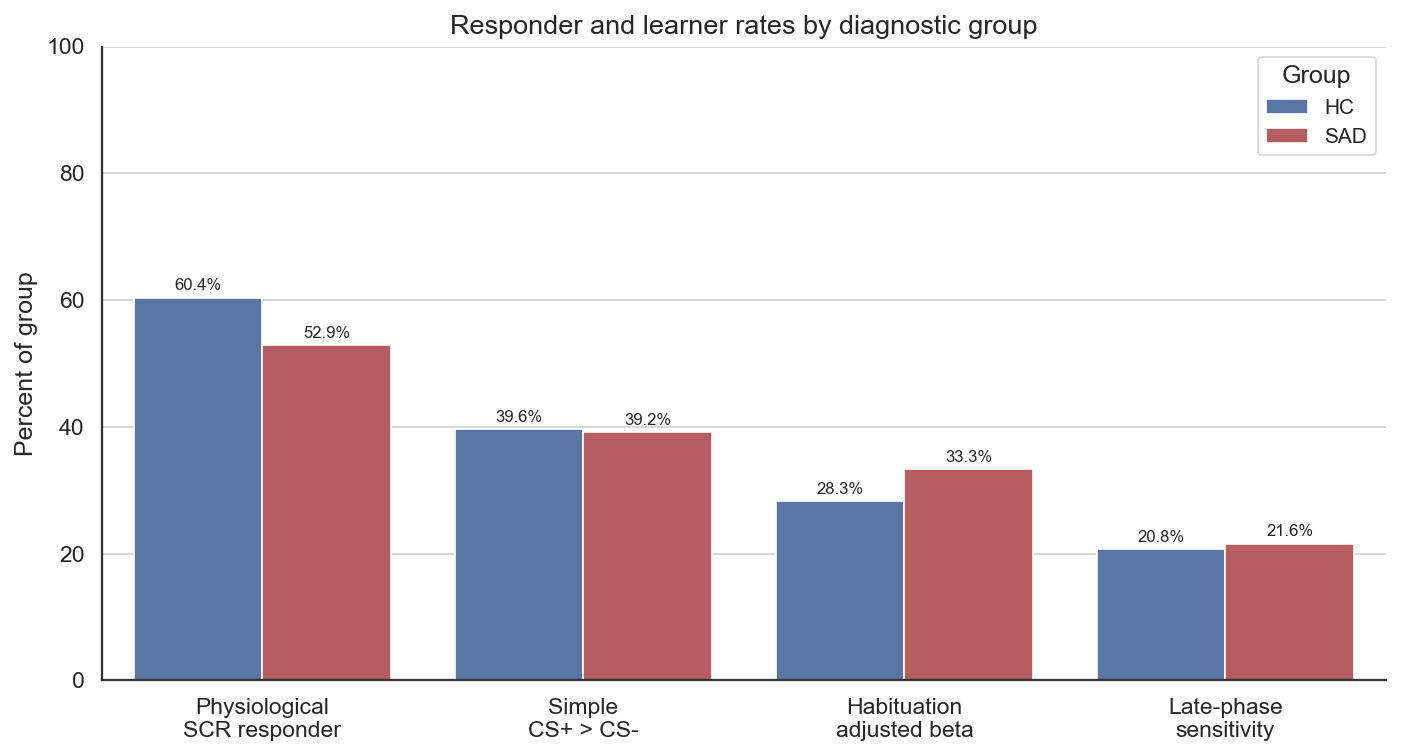

In [4]:
def build_physio_flags(acq_df):
    rows = []
    for subject, g in acq_df.groupby("Subject"):
        csplus = g[g["Domain"] == "CS+"]
        css = g[g["Condition"] == "CSS"]
        csr = g[g["Condition"] == "CSR"]
        rows.append({
            "Subject": subject,
            "n_raw_CSplus_ge_0p05": int((csplus[RAW_COL] >= PHYSIO_RESPONDER_THRESHOLD_RAW).sum()),
            "n_raw_CSS_ge_0p05": int((css[RAW_COL] >= PHYSIO_RESPONDER_THRESHOLD_RAW).sum()),
            "n_raw_CSR_ge_0p05": int((csr[RAW_COL] >= PHYSIO_RESPONDER_THRESHOLD_RAW).sum()),
        })
    out = pd.DataFrame(rows)
    out["physiological_responder_CSplus"] = out["n_raw_CSplus_ge_0p05"] >= PHYSIO_RESPONDER_MIN_CSPLUS_TRIALS
    out["physiological_responder_CSS"] = out["n_raw_CSS_ge_0p05"] >= PHYSIO_RESPONDER_MIN_CSPLUS_TRIALS
    out["physiological_responder_CSR"] = out["n_raw_CSR_ge_0p05"] >= PHYSIO_RESPONDER_MIN_CSPLUS_TRIALS
    return out


def build_simple_differential_flags(acq_df):
    rows = []
    for subject, g in acq_df.groupby("Subject"):
        csminus = g[g["Condition"] == "CS-"]
        csplus = g[g["Domain"] == "CS+"]
        css = g[g["Condition"] == "CSS"]
        csr = g[g["Condition"] == "CSR"]
        rows.append({
            "Subject": subject,
            "simple_diff_CSplus": safe_mean(csplus[SCORE_COL]) - safe_mean(csminus[SCORE_COL]),
            "simple_diff_CSS": safe_mean(css[SCORE_COL]) - safe_mean(csminus[SCORE_COL]),
            "simple_diff_CSR": safe_mean(csr[SCORE_COL]) - safe_mean(csminus[SCORE_COL]),
        })
    return pd.DataFrame(rows)


def _beta_for_subject(g, target_conditions, label):
    d = g[g["Condition"].isin(["CS-"] + list(target_conditions))].copy()
    if d.empty or d["Condition"].nunique() < 2:
        return {f"habituation_beta_{label}": np.nan, f"habituation_beta_trial_{label}": np.nan, f"habituation_n_{label}": int(len(d))}
    y = d[SCORE_COL].astype(float).to_numpy()
    csplus_indicator = d["Condition"].isin(target_conditions).astype(float).to_numpy()
    trial_z = d["Trial_Z"].astype(float).to_numpy()
    X = np.column_stack([np.ones(len(d)), csplus_indicator, trial_z])
    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
    except np.linalg.LinAlgError:
        beta = [np.nan, np.nan, np.nan]
    return {f"habituation_beta_{label}": float(beta[1]), f"habituation_beta_trial_{label}": float(beta[2]), f"habituation_n_{label}": int(len(y))}


def build_habituation_adjusted_flags(acq_df):
    rows = []
    targets = {"CSplus": ["CSS", "CSR"], "CSS": ["CSS"], "CSR": ["CSR"]}
    for subject, g in acq_df.groupby("Subject"):
        row = {"Subject": subject}
        for label, target_conditions in targets.items():
            row.update(_beta_for_subject(g, target_conditions, label))
        rows.append(row)
    return pd.DataFrame(rows)


def build_late_phase_sensitivity_flags(acq_df):
    rows = []
    targets = {"CSplus": ["CSS", "CSR"], "CSS": ["CSS"], "CSR": ["CSR"]}
    for subject, g in acq_df.groupby("Subject"):
        row = {"Subject": subject}
        for label, target_conditions in targets.items():
            target = g[g["Condition"].isin(target_conditions)]
            csminus = g[g["Condition"] == "CS-"]
            early_diff = safe_mean(target[target["Window"] == "Early"][SCORE_COL]) - safe_mean(csminus[csminus["Window"] == "Early"][SCORE_COL])
            late_diff = safe_mean(target[target["Window"] == "Late"][SCORE_COL]) - safe_mean(csminus[csminus["Window"] == "Late"][SCORE_COL])
            row[f"late_phase_diff_early_{label}"] = early_diff
            row[f"late_phase_diff_late_{label}"] = late_diff
            row[f"late_phase_diff_change_{label}"] = late_diff - early_diff
            row[f"late_phase_learner_{label}"] = (late_diff > 0) and ((late_diff - early_diff) > 0)
        rows.append(row)
    return pd.DataFrame(rows)

acq_for_learners = all_scr[all_scr["Phase"] == "Acquisition"].copy()
physio_flags = build_physio_flags(acq_for_learners)
simple_flags = build_simple_differential_flags(acq_for_learners)
habituation_flags = build_habituation_adjusted_flags(acq_for_learners)
late_phase_flags = build_late_phase_sensitivity_flags(acq_for_learners)
learner_df = physio_flags.merge(simple_flags, on="Subject", how="outer").merge(habituation_flags, on="Subject", how="outer").merge(late_phase_flags, on="Subject", how="outer")
for label in ["CSplus", "CSS", "CSR"]:
    learner_df[f"simple_learner_{label}"] = learner_df["physiological_responder_CSplus"] & (learner_df[f"simple_diff_{label}"] > 0)
    learner_df[f"habituation_adjusted_learner_{label}"] = learner_df["physiological_responder_CSplus"] & (learner_df[f"habituation_beta_{label}"] > 0)
    learner_df[f"late_phase_sensitivity_learner_{label}"] = learner_df[f"late_phase_learner_{label}"].astype(bool)
for prefix in ["simple_learner", "habituation_adjusted_learner", "late_phase_sensitivity_learner"]:
    learner_df[f"{prefix}_either_CSS_or_CSR"] = learner_df[[f"{prefix}_CSS", f"{prefix}_CSR"]].any(axis=1)
    learner_df[f"{prefix}_both_CSS_and_CSR"] = learner_df[[f"{prefix}_CSS", f"{prefix}_CSR"]].all(axis=1)
learner_df = learner_df.merge(meta, on="Subject", how="left") if not meta.empty else learner_df

def summarize_definitions(df, by=None):
    definitions = [
        ("Physiological SCR responder", "physiological_responder_CSplus"),
        ("Simple acquisition differential: pooled CS+ > CS-", "simple_learner_CSplus"),
        ("Habituation-adjusted beta: pooled CS+ > CS-", "habituation_adjusted_learner_CSplus"),
        ("Late-phase sensitivity: pooled CS+", "late_phase_sensitivity_learner_CSplus"),
    ]
    rows = []
    if by is None:
        groups = [((), df)]
        by_cols = []
    else:
        by_cols = list(by)
        groups = list(df.groupby(by_cols, dropna=False))
    for key, sub in groups:
        if not isinstance(key, tuple):
            key = (key,)
        base = {col: val for col, val in zip(by_cols, key)}
        denom = sub["Subject"].nunique()
        for definition, col in definitions:
            n = int(sub[col].fillna(False).sum()) if col in sub else 0
            rows.append({**base, "Definition": definition, "N": n, "Total": denom, "Percent_of_total": safe_percent(n, denom)})
    return pd.DataFrame(rows)

learner_summary = summarize_definitions(learner_df)
learner_by_group = summarize_definitions(learner_df, by=["Group"]) if "Group" in learner_df.columns else pd.DataFrame()
learner_by_group_drug = summarize_definitions(learner_df, by=["Group", "Drug"]) if {"Group", "Drug"}.issubset(learner_df.columns) else pd.DataFrame()

print("Overall learner rates")
display(learner_summary)
print("Learner rates by Group")
display(learner_by_group)
print("Learner rates by Group x Drug")
display(learner_by_group_drug)

analysis_sets = {
    "All subjects": set(learner_df["Subject"]),
    "Physiological responders": set(learner_df.loc[learner_df["physiological_responder_CSplus"].fillna(False), "Subject"]),
    "Simple CS+ learners": set(learner_df.loc[learner_df["simple_learner_CSplus"].fillna(False), "Subject"]),
    "Habituation-adjusted CS+ learners": set(learner_df.loc[learner_df["habituation_adjusted_learner_CSplus"].fillna(False), "Subject"]),
    "Late-phase sensitivity CS+ learners": set(learner_df.loc[learner_df["late_phase_sensitivity_learner_CSplus"].fillna(False), "Subject"]),
}

plot_defs = {
    "Physiological SCR responder": "Physiological\nSCR responder",
    "Simple acquisition differential: pooled CS+ > CS-": "Simple\nCS+ > CS-",
    "Habituation-adjusted beta: pooled CS+ > CS-": "Habituation\nadjusted beta",
    "Late-phase sensitivity: pooled CS+": "Late-phase\nsensitivity",
}
plot_df = learner_by_group[learner_by_group["Definition"].isin(plot_defs)].copy()
plot_df["Definition_short"] = plot_df["Definition"].map(plot_defs)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.barplot(data=plot_df, x="Definition_short", y="Percent_of_total", hue="Group", hue_order=GROUP_ORDER, palette=GROUP_PALETTE, ax=ax)
ax.set_title("Responder and learner rates by diagnostic group")
ax.set_ylabel("Percent of group")
ax.set_xlabel("")
ax.set_ylim(0, max(100, plot_df["Percent_of_total"].max() * 1.2 if not plot_df.empty else 100))
clean_axis(ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
save_current_fig("scr_responder_learner_rates_by_group.png")
plt.show()



## 5. Statistical Helpers


In [5]:
def subject_window_contrast_scores(df, phase, subject_set, window="All"):
    sub = df[(df["Phase"] == phase) & (df["Subject"].isin(subject_set))].copy()
    if window != "All":
        sub = sub[sub["Window"] == window]
    rows = []
    for subject, g in sub.groupby("Subject"):
        group = g["Group"].dropna().iloc[0] if g["Group"].notna().any() else np.nan
        drug = g["Drug"].dropna().iloc[0] if "Drug" in g and g["Drug"].notna().any() else np.nan
        csminus = safe_mean(g.loc[g["Condition"] == "CS-", SCORE_COL])
        csplus = safe_mean(g.loc[g["Domain"] == "CS+", SCORE_COL])
        css = safe_mean(g.loc[g["Condition"] == "CSS", SCORE_COL])
        csr = safe_mean(g.loc[g["Condition"] == "CSR", SCORE_COL])
        rows.extend([
            {"Subject": subject, "Group": group, "Drug": drug, "Phase": phase, "Window": window, "Contrast": "CS+ - CS-", "Score": csplus - csminus},
            {"Subject": subject, "Group": group, "Drug": drug, "Phase": phase, "Window": window, "Contrast": "CSS - CS-", "Score": css - csminus},
            {"Subject": subject, "Group": group, "Drug": drug, "Phase": phase, "Window": window, "Contrast": "CSR - CS-", "Score": csr - csminus},
        ])
    return pd.DataFrame(rows).dropna(subset=["Score"])


def within_and_group_stats(score_df, analysis_set, effect_label, alternative="greater"):
    rows = []
    for contrast in CONTRAST_ORDER:
        subc = score_df[score_df["Contrast"] == contrast].copy()
        for group in GROUP_ORDER:
            vals = subc.loc[subc["Group"] == group, "Score"].dropna()
            if len(vals) >= 2:
                tres = stats.ttest_1samp(vals, 0.0, alternative=alternative)
                d = vals.mean() / vals.std(ddof=1) if vals.std(ddof=1) > 0 else np.nan
            else:
                tres = None
                d = np.nan
            rows.append({
                "AnalysisSet": analysis_set,
                "Effect": effect_label,
                "Contrast": contrast,
                "Test": f"{group} vs 0",
                "Group": group,
                "N": int(len(vals)),
                "Mean": float(vals.mean()) if len(vals) else np.nan,
                "SE": float(vals.sem()) if len(vals) > 1 else np.nan,
                "t": float(tres.statistic) if tres is not None else np.nan,
                "p": float(tres.pvalue) if tres is not None else np.nan,
                "Cohen_d": float(d) if not pd.isna(d) else np.nan,
            })
        sad = subc.loc[subc["Group"] == "SAD", "Score"].dropna()
        hc = subc.loc[subc["Group"] == "HC", "Score"].dropna()
        if len(sad) >= 2 and len(hc) >= 2:
            gres = stats.ttest_ind(sad, hc, equal_var=False, alternative="two-sided")
            denom = math.sqrt(sad.var(ddof=1) / len(sad) + hc.var(ddof=1) / len(hc))
            d = (sad.mean() - hc.mean()) / np.sqrt(((len(sad) - 1) * sad.var(ddof=1) + (len(hc) - 1) * hc.var(ddof=1)) / (len(sad) + len(hc) - 2)) if (len(sad) + len(hc) - 2) > 0 else np.nan
        else:
            gres = None
            d = np.nan
        rows.append({
            "AnalysisSet": analysis_set,
            "Effect": effect_label,
            "Contrast": contrast,
            "Test": "SAD vs HC",
            "Group": "SAD-HC",
            "N": int(len(sad) + len(hc)),
            "Mean": float(sad.mean() - hc.mean()) if len(sad) and len(hc) else np.nan,
            "SE": np.nan,
            "t": float(gres.statistic) if gres is not None else np.nan,
            "p": float(gres.pvalue) if gres is not None else np.nan,
            "Cohen_d": float(d) if not pd.isna(d) else np.nan,
        })
    return pd.DataFrame(rows)


def phase_effect_tables(df, phase, analysis_sets, windows=("All",), alternative="greater"):
    score_tables = []
    stat_tables = []
    for set_name in ANALYSIS_SET_ORDER:
        if set_name not in analysis_sets:
            continue
        subjects = analysis_sets[set_name]
        for window in windows:
            scores = subject_window_contrast_scores(df, phase, subjects, window=window)
            scores["AnalysisSet"] = set_name
            effect = f"{phase}: {window} condition contrast"
            stats_df = within_and_group_stats(scores, set_name, effect, alternative=alternative)
            score_tables.append(scores)
            stat_tables.append(stats_df)
    return pd.concat(score_tables, ignore_index=True), pd.concat(stat_tables, ignore_index=True)


def window_change_scores(df, phase, subject_set):
    early = subject_window_contrast_scores(df, phase, subject_set, window="Early")
    late = subject_window_contrast_scores(df, phase, subject_set, window="Late")
    merged = early.merge(late, on=["Subject", "Group", "Drug", "Phase", "Contrast"], suffixes=("_Early", "_Late"))
    merged["Score"] = merged["Score_Late"] - merged["Score_Early"]
    merged["Window"] = "Late - Early"
    return merged[["Subject", "Group", "Drug", "Phase", "Window", "Contrast", "Score", "Score_Early", "Score_Late"]]


def window_change_tables(df, phase, analysis_sets, alternative="less"):
    score_tables = []
    stat_tables = []
    for set_name in ANALYSIS_SET_ORDER:
        if set_name not in analysis_sets:
            continue
        scores = window_change_scores(df, phase, analysis_sets[set_name])
        scores["AnalysisSet"] = set_name
        effect = f"{phase}: late minus early discrimination"
        stats_df = within_and_group_stats(scores, set_name, effect, alternative=alternative)
        score_tables.append(scores)
        stat_tables.append(stats_df)
    return pd.concat(score_tables, ignore_index=True), pd.concat(stat_tables, ignore_index=True)


def reinstatement_return_scores(df, subject_set):
    ext_late = subject_window_contrast_scores(df, "Extinction", subject_set, window="Late")
    rein_early = subject_window_contrast_scores(df, "Reinstatement", subject_set, window="Early")
    merged = ext_late.merge(rein_early, on=["Subject", "Group", "Drug", "Contrast"], suffixes=("_ExtLate", "_ReinEarly"))
    merged["Score"] = merged["Score_ReinEarly"] - merged["Score_ExtLate"]
    merged["Phase"] = "Reinstatement return"
    merged["Window"] = "Reinstatement Early - Extinction Late"
    return merged[["Subject", "Group", "Drug", "Phase", "Window", "Contrast", "Score", "Score_ExtLate", "Score_ReinEarly"]]


def reinstatement_return_tables(df, analysis_sets):
    score_tables = []
    stat_tables = []
    for set_name in ANALYSIS_SET_ORDER:
        if set_name not in analysis_sets:
            continue
        scores = reinstatement_return_scores(df, analysis_sets[set_name])
        scores["AnalysisSet"] = set_name
        stats_df = within_and_group_stats(scores, set_name, "Reinstatement: early return over late extinction", alternative="greater")
        score_tables.append(scores)
        stat_tables.append(stats_df)
    return pd.concat(score_tables, ignore_index=True), pd.concat(stat_tables, ignore_index=True)


def add_group_sig_labels(ax, stats_df, analysis_set, effect_contains=None, y_pad=0.06):
    if stats_df is None or stats_df.empty:
        return
    sub = stats_df[(stats_df["AnalysisSet"] == analysis_set) & (stats_df["Test"] == "SAD vs HC")].copy()
    if effect_contains:
        sub = sub[sub["Effect"].astype(str).str.contains(effect_contains, regex=False)]
    if sub.empty:
        return
    xticks = ax.get_xticks()
    labels = [t.get_text() for t in ax.get_xticklabels()]
    y_min, y_max = ax.get_ylim()
    span = y_max - y_min if y_max > y_min else 1
    for _, row in sub.iterrows():
        stars = p_to_stars(row["p"])
        if not stars:
            continue
        contrast = row["Contrast"]
        if contrast not in labels:
            continue
        x = xticks[labels.index(contrast)]
        local = ax.collections + ax.patches
        y = y_max - span * y_pad
        ax.text(x, y, stars, ha="center", va="bottom", fontsize=13, fontweight="bold", color="black")
        ax.text(x, y - span * 0.055, p_text(row["p"]), ha="center", va="bottom", fontsize=8, color="black")


def plot_group_contrast_bars(score_df, stats_df, analysis_set, title, filename, ylim_zero=True):
    sub = score_df[score_df["AnalysisSet"] == analysis_set].copy()
    if sub.empty:
        print(f"No data for {analysis_set}: {title}")
        return
    fig, ax = plt.subplots(figsize=(8.2, 5))
    sns.barplot(data=sub, x="Contrast", y="Score", hue="Group", order=CONTRAST_ORDER, hue_order=GROUP_ORDER, palette=GROUP_PALETTE, errorbar="se", capsize=0.12, err_kws={"linewidth": 1.4}, ax=ax)
    sns.stripplot(data=sub, x="Contrast", y="Score", hue="Group", order=CONTRAST_ORDER, hue_order=GROUP_ORDER, palette=GROUP_PALETTE, dodge=True, alpha=0.45, size=3.2, linewidth=0.2, edgecolor="white", ax=ax)
    ax.axhline(0, color="#222222", linewidth=1.1)
    ax.set_title(title)
    ax.set_ylabel("Subject-level contrast (sqrt SCR)")
    ax.set_xlabel("")
    clean_axis(ax)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Group", frameon=True, loc="best")
    add_group_sig_labels(ax, stats_df, analysis_set)
    plt.tight_layout()
    save_current_fig(filename)
    plt.show()


def plot_trialwise_by_group(df, phase, analysis_set, subject_set, filename):
    plot_df = df[(df["Phase"] == phase) & (df["Subject"].isin(subject_set))].copy()
    if plot_df.empty:
        print(f"No trialwise data for {phase} / {analysis_set}")
        return
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
    for ax, condition in zip(axes, CONDITION_ORDER):
        sub = plot_df[plot_df["Condition"] == condition]
        sns.lineplot(data=sub, x="ConditionTrial", y=SCORE_COL, hue="Group", hue_order=GROUP_ORDER, palette=GROUP_PALETTE, marker="o", linewidth=2, errorbar="se", ax=ax)
        ax.set_title(condition)
        ax.set_xlabel("Condition-specific trial")
        ax.set_ylabel("sqrt SCR" if condition == "CS-" else "")
        clean_axis(ax)
        if condition != "CSR":
            ax.legend_.remove()
    fig.suptitle(f"{phase}: trial-wise thresholded sqrt SCR ({analysis_set})", y=1.03)
    plt.tight_layout()
    save_current_fig(filename)
    plt.show()


## 6. Acquisition: Fear-Learning Effect


Acquisition condition-contrast statistics


,AnalysisSet,Effect,Contrast,Test,Group,N,Mean,SE,t,p,Cohen_d
0,All subjects,Acquisition: All condition contrast,CS+ - CS-,HC vs 0,HC,53,0.019394,0.008064,2.404960,0.009884,0.330347
1,All subjects,Acquisition: All condition contrast,CS+ - CS-,SAD vs 0,SAD,51,0.011485,0.007700,1.491666,0.071035,0.208875
2,All subjects,Acquisition: All condition contrast,CS+ - CS-,SAD vs HC,SAD-HC,104,-0.007909,NaN,-0.709336,0.479735,-0.138961
3,All subjects,Acquisition: All condition contrast,CSS - CS-,HC vs 0,HC,53,0.024637,0.008297,2.969224,0.002254,0.407854
4,All subjects,Acquisition: All condition contrast,CSS - CS-,SAD vs 0,SAD,51,0.013060,0.010124,1.289940,0.101503,0.180628
5,All subjects,Acquisition: All condition contrast,CSS - CS-,SAD vs HC,SAD-HC,104,-0.011577,NaN,-0.884425,0.378644,-0.174082
6,All subjects,Acquisition: All condition contrast,CSR - CS-,HC vs 0,HC,53,0.014152,0.009584,1.476622,0.072904,0.202830
7,All subjects,Acquisition: All condition contrast,CSR - CS-,SAD vs 0,SAD,51,0.009911,0.007732,1.281880,0.102898,0.179499
8,All subjects,Acquisition: All condition contrast,CSR - CS-,SAD vs HC,SAD-HC,104,-0.004241,NaN,-0.344398,0.731282,-0.067254
9,All subjects,Acquisition: Early condition contrast,CS+ - CS-,HC vs 0,HC,53,0.025650,0.011488,2.232804,0.014946,0.306699


Acquisition late-minus-early change statistics


,AnalysisSet,Effect,Contrast,Test,Group,N,Mean,SE,t,p,Cohen_d
0,All subjects,Acquisition: late minus early discrimination,CS+ - CS-,HC vs 0,HC,53,-0.012512,0.012246,-1.021690,0.844171,-0.140340
1,All subjects,Acquisition: late minus early discrimination,CS+ - CS-,SAD vs 0,SAD,51,-0.009224,0.012908,-0.714648,0.760925,-0.100071
2,All subjects,Acquisition: late minus early discrimination,CS+ - CS-,SAD vs HC,SAD-HC,104,0.003287,NaN,0.184755,0.853790,0.036264
3,All subjects,Acquisition: late minus early discrimination,CSS - CS-,HC vs 0,HC,53,-0.028968,0.012186,-2.377173,0.989420,-0.326530
4,All subjects,Acquisition: late minus early discrimination,CSS - CS-,SAD vs 0,SAD,51,-0.021379,0.015264,-1.400646,0.916252,-0.196130
5,All subjects,Acquisition: late minus early discrimination,CSS - CS-,SAD vs HC,SAD-HC,104,0.007589,NaN,0.388550,0.698466,0.076516
6,All subjects,Acquisition: late minus early discrimination,CSR - CS-,HC vs 0,HC,53,0.003944,0.017048,0.231377,0.408965,0.031782
7,All subjects,Acquisition: late minus early discrimination,CSR - CS-,SAD vs 0,SAD,51,0.002930,0.015472,0.189371,0.425284,0.026517
8,All subjects,Acquisition: late minus early discrimination,CSR - CS-,SAD vs HC,SAD-HC,104,-0.001014,NaN,-0.044061,0.964943,-0.008623
9,Physiological responders,Acquisition: late minus early discrimination,CS+ - CS-,HC vs 0,HC,32,-0.018120,0.019687,-0.920434,0.817773,-0.162711


Saved figure -> scr_analysis_outputs/figures/scr_acquisition_trialwise_by_group_all_subjects.png


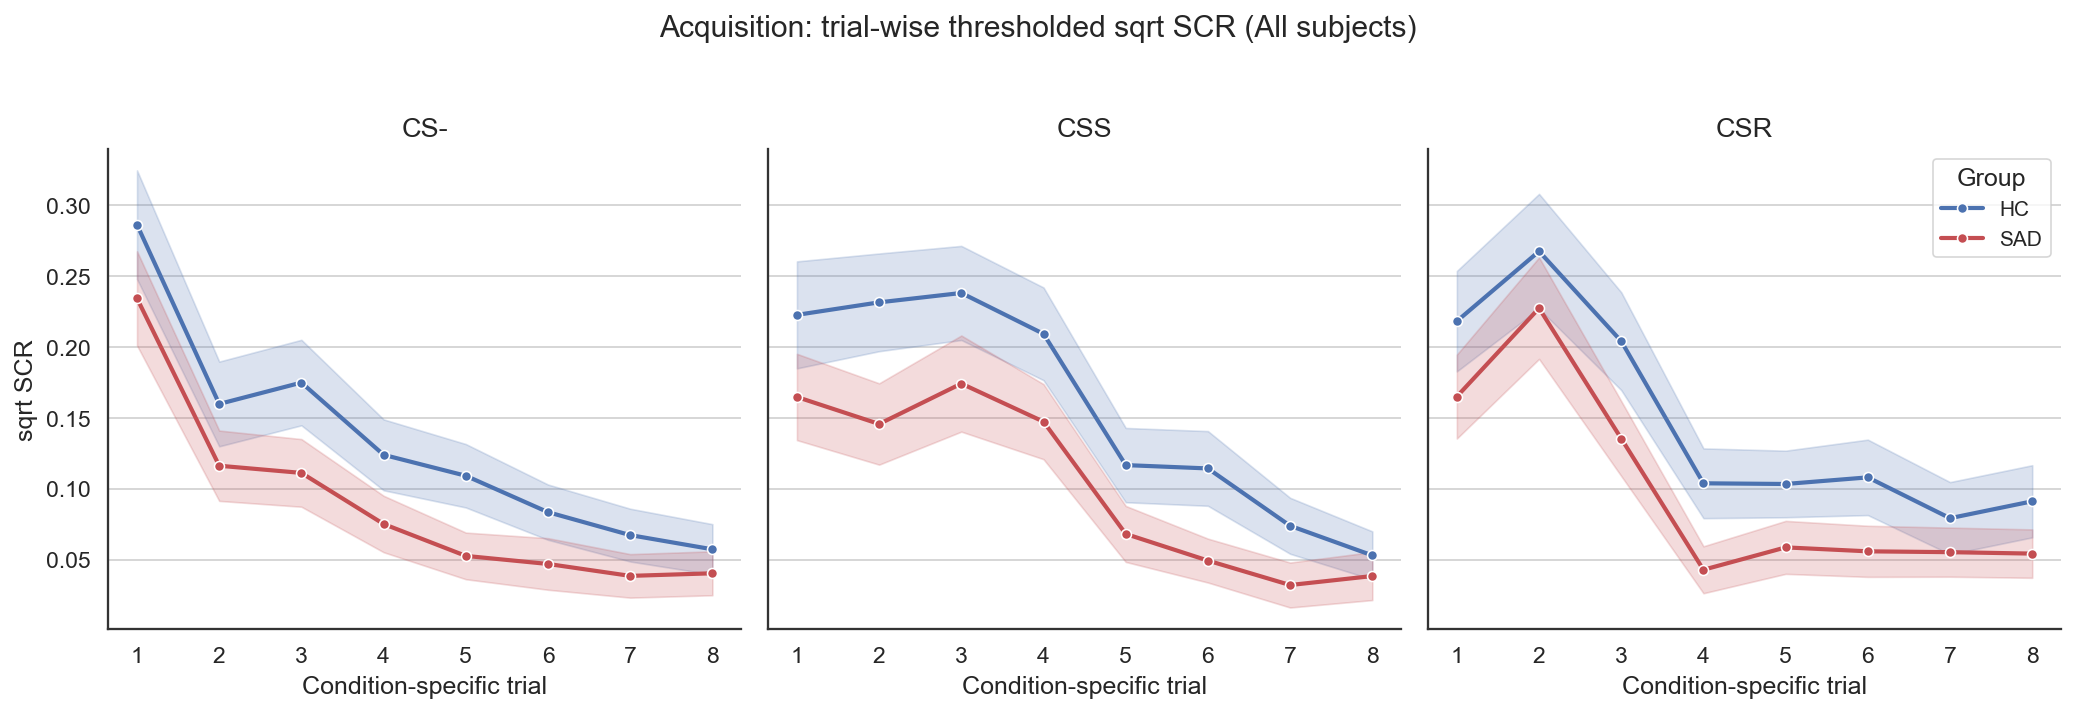

Saved figure -> scr_analysis_outputs/figures/scr_acquisition_group_contrasts_all_subjects.png


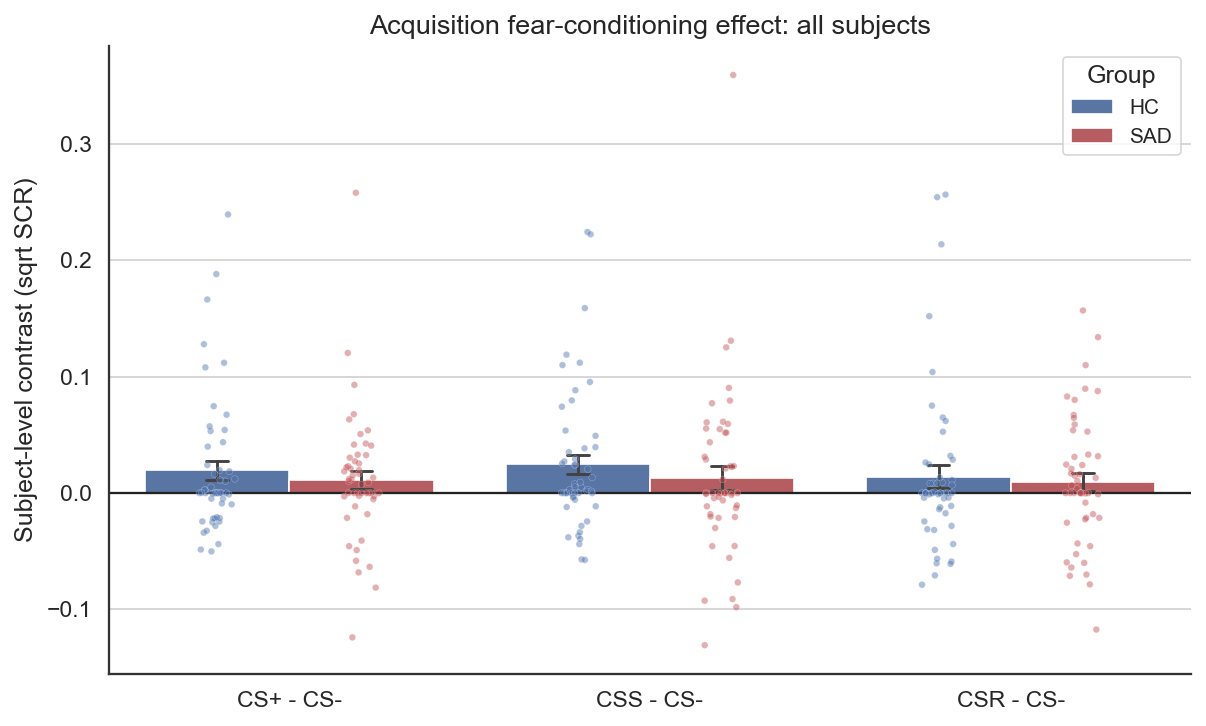

Saved figure -> scr_analysis_outputs/figures/scr_acquisition_group_contrasts_physiological_responders.png


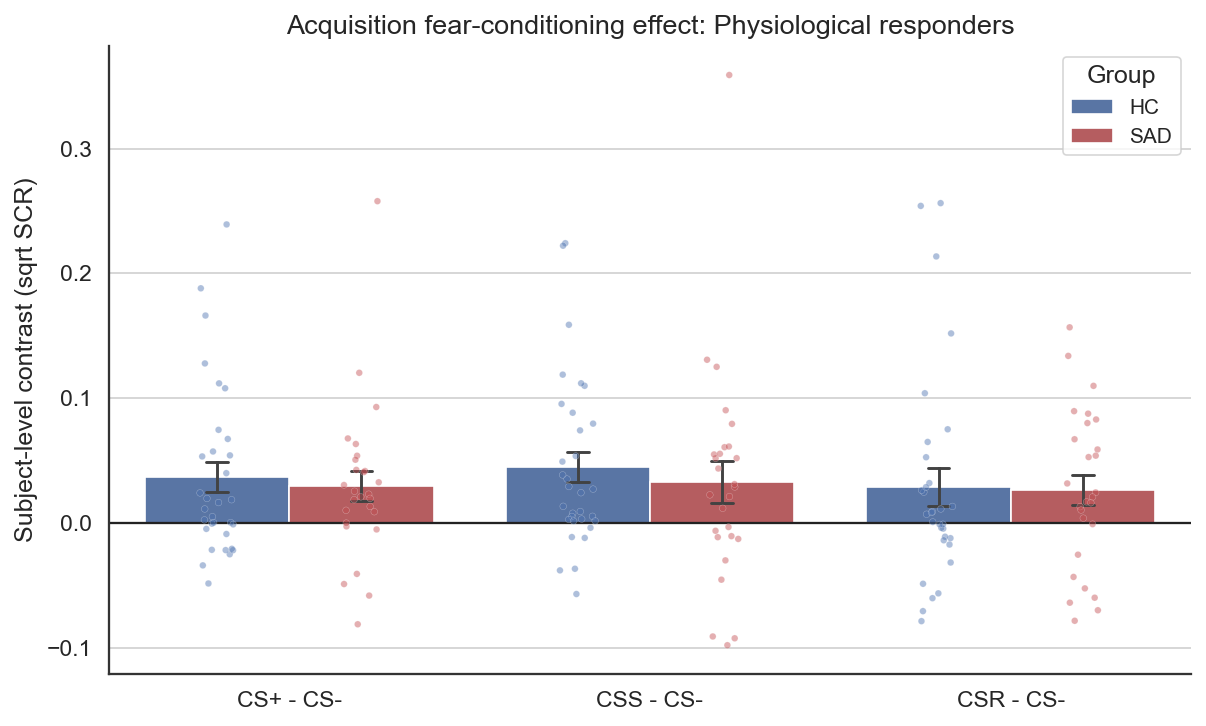

Saved figure -> scr_analysis_outputs/figures/scr_acquisition_group_contrasts_simple_csplus_learners.png


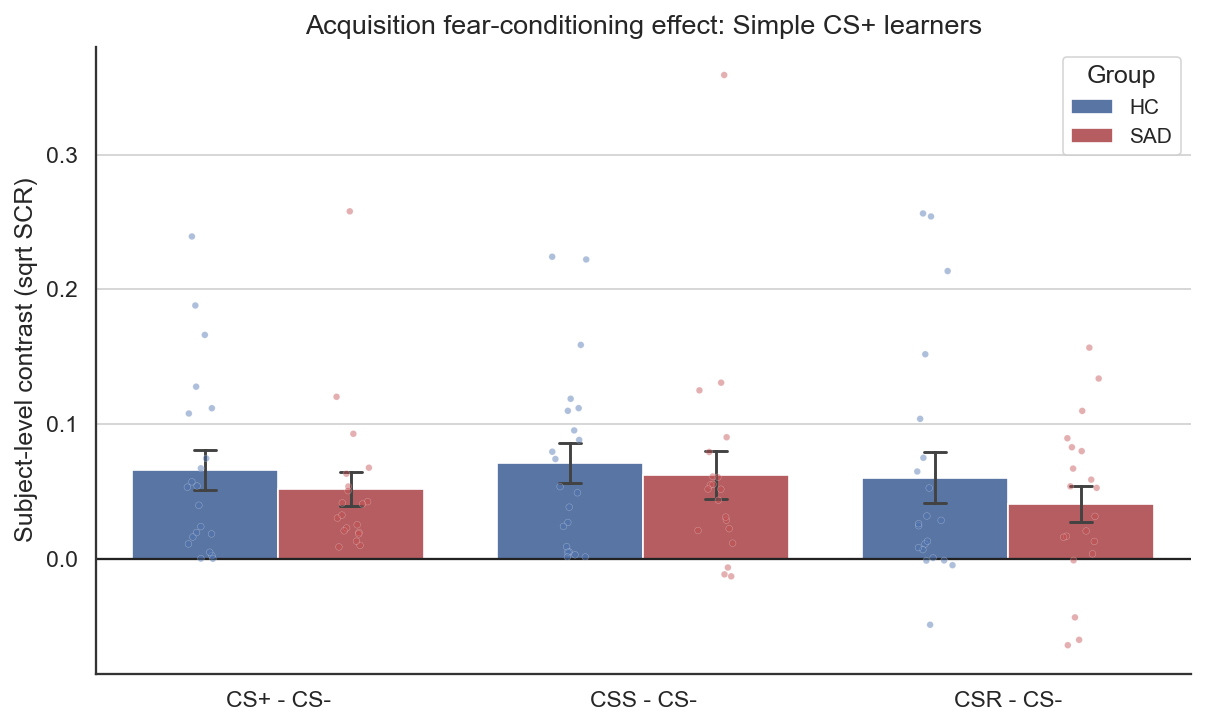

Saved figure -> scr_analysis_outputs/figures/scr_acquisition_group_contrasts_habituationadjusted_csplus_learners.png


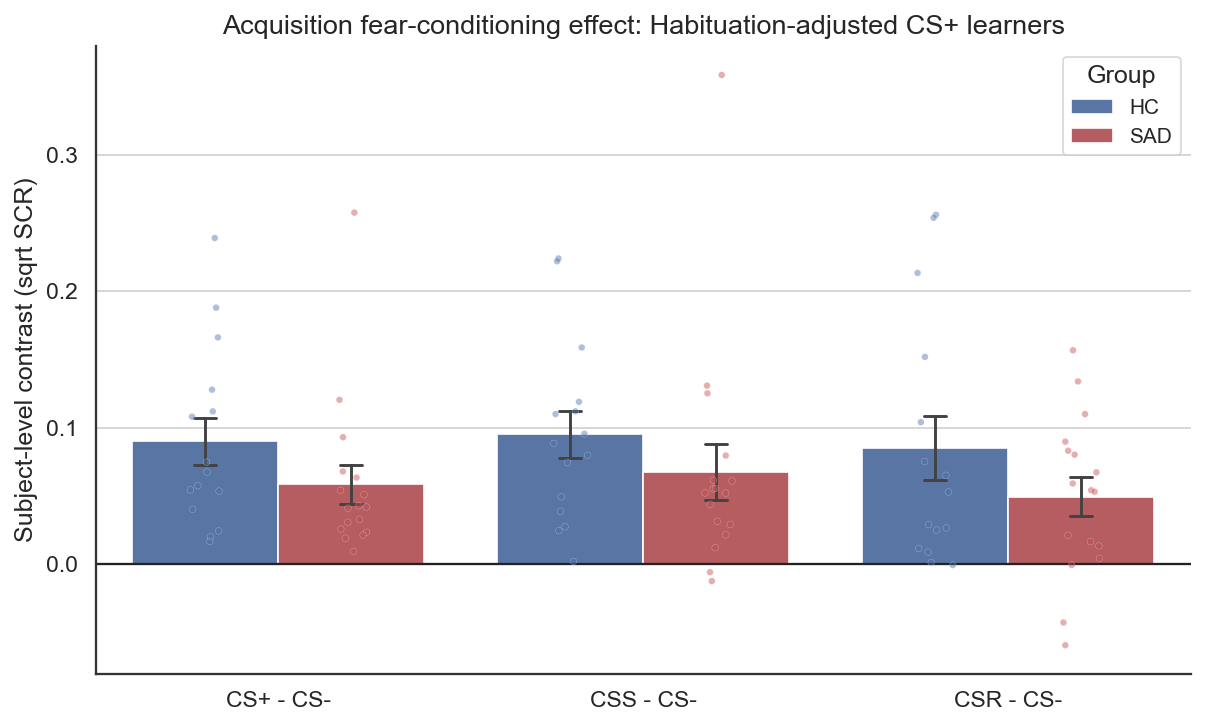

Saved figure -> scr_analysis_outputs/figures/scr_acquisition_group_contrasts_latephase_sensitivity_csplus_learners.png


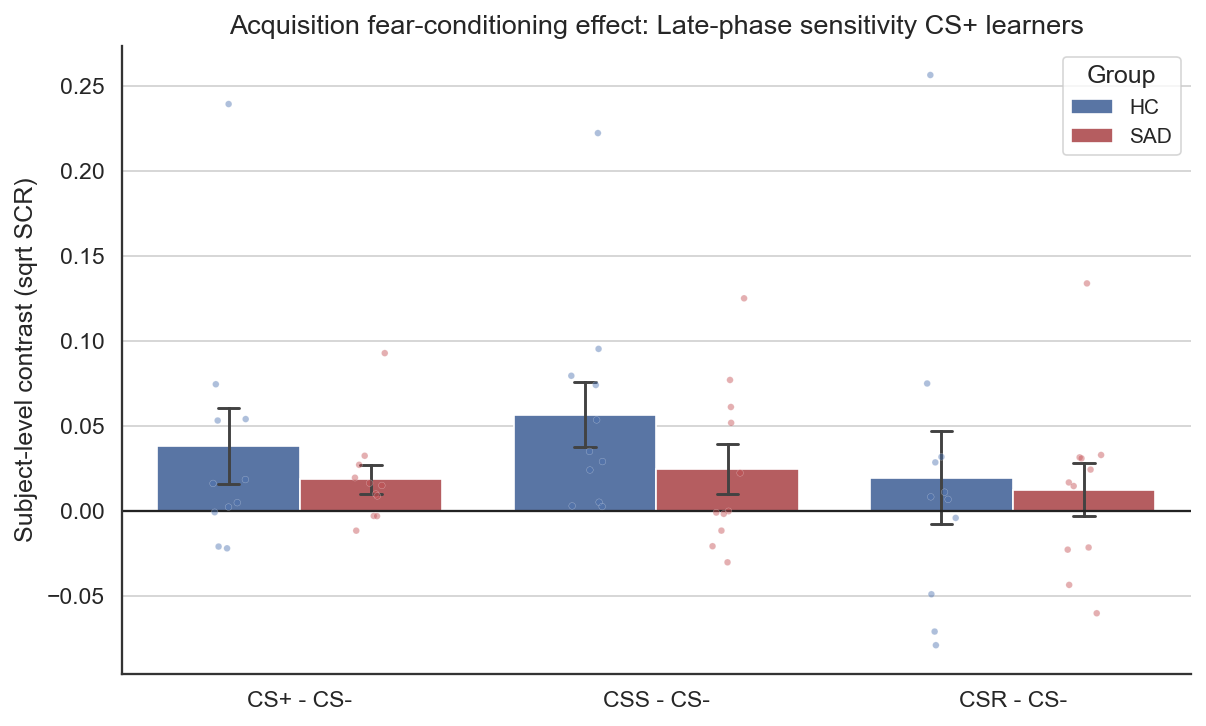

In [6]:
acq_scores, acq_stats = phase_effect_tables(all_scr, "Acquisition", analysis_sets, windows=("All", "Early", "Late"), alternative="greater")
acq_change_scores, acq_change_stats = window_change_tables(all_scr, "Acquisition", analysis_sets, alternative="greater")
print("Acquisition condition-contrast statistics")
display(acq_stats)
print("Acquisition late-minus-early change statistics")
display(acq_change_stats)
plot_trialwise_by_group(all_scr, "Acquisition", "All subjects", analysis_sets["All subjects"], "scr_acquisition_trialwise_by_group_all_subjects.png")
plot_group_contrast_bars(acq_scores[acq_scores["Window"] == "All"], acq_stats[acq_stats["Effect"].str.contains("All")], "All subjects", "Acquisition fear-conditioning effect: all subjects", "scr_acquisition_group_contrasts_all_subjects.png")
for set_name in ["Physiological responders", "Simple CS+ learners", "Habituation-adjusted CS+ learners", "Late-phase sensitivity CS+ learners"]:
    plot_group_contrast_bars(acq_scores[acq_scores["Window"] == "All"], acq_stats[acq_stats["Effect"].str.contains("All")], set_name, f"Acquisition fear-conditioning effect: {set_name}", f"scr_acquisition_group_contrasts_{set_name.lower().replace(' ', '_').replace('+', 'plus').replace('-', '')}.png")


## 7. Extinction: Reduction Of Fear-Conditioned Responding


Extinction condition-contrast statistics


,AnalysisSet,Effect,Contrast,Test,Group,N,Mean,SE,t,p,Cohen_d
0,All subjects,Extinction: All condition contrast,CS+ - CS-,HC vs 0,HC,52,0.005969,0.006780,0.880443,0.191375,0.122095
1,All subjects,Extinction: All condition contrast,CS+ - CS-,SAD vs 0,SAD,49,-0.008278,0.007118,-1.163084,0.874727,-0.166155
2,All subjects,Extinction: All condition contrast,CS+ - CS-,SAD vs HC,SAD-HC,101,-0.014248,NaN,-1.449420,0.150400,-0.288736
3,All subjects,Extinction: All condition contrast,CSS - CS-,HC vs 0,HC,52,0.011398,0.007999,1.425015,0.080122,0.197614
4,All subjects,Extinction: All condition contrast,CSS - CS-,SAD vs 0,SAD,49,-0.005175,0.008019,-0.645370,0.739120,-0.092196
5,All subjects,Extinction: All condition contrast,CSS - CS-,SAD vs HC,SAD-HC,101,-0.016574,NaN,-1.463269,0.146565,-0.291093
6,All subjects,Extinction: All condition contrast,CSR - CS-,HC vs 0,HC,52,0.000541,0.006743,0.080170,0.468208,0.011118
7,All subjects,Extinction: All condition contrast,CSR - CS-,SAD vs 0,SAD,49,-0.011381,0.007743,-1.469989,0.925955,-0.209998
8,All subjects,Extinction: All condition contrast,CSR - CS-,SAD vs HC,SAD-HC,101,-0.011922,NaN,-1.161148,0.248452,-0.231930
9,All subjects,Extinction: Early condition contrast,CS+ - CS-,HC vs 0,HC,52,0.004529,0.009720,0.465990,0.321604,0.064621


Extinction late-minus-early reduction statistics


,AnalysisSet,Effect,Contrast,Test,Group,N,Mean,SE,t,p,Cohen_d
0,All subjects,Extinction: late minus early discrimination,CS+ - CS-,HC vs 0,HC,52,0.002880,0.011110,0.259229,0.601749,0.035949
1,All subjects,Extinction: late minus early discrimination,CS+ - CS-,SAD vs 0,SAD,49,0.001953,0.012756,0.153072,0.560508,0.021867
2,All subjects,Extinction: late minus early discrimination,CS+ - CS-,SAD vs HC,SAD-HC,101,-0.000927,NaN,-0.054827,0.956390,-0.010951
3,All subjects,Extinction: late minus early discrimination,CSS - CS-,HC vs 0,HC,52,0.001486,0.014569,0.101965,0.540408,0.014140
4,All subjects,Extinction: late minus early discrimination,CSS - CS-,SAD vs 0,SAD,49,-0.008594,0.015122,-0.568287,0.286245,-0.081184
5,All subjects,Extinction: late minus early discrimination,CSS - CS-,SAD vs HC,SAD-HC,101,-0.010079,NaN,-0.480001,0.632291,-0.095588
6,All subjects,Extinction: late minus early discrimination,CSR - CS-,HC vs 0,HC,52,0.004274,0.010850,0.393940,0.652366,0.054630
7,All subjects,Extinction: late minus early discrimination,CSR - CS-,SAD vs 0,SAD,49,0.012499,0.012552,0.995801,0.837830,0.142257
8,All subjects,Extinction: late minus early discrimination,CSR - CS-,SAD vs HC,SAD-HC,101,0.008225,NaN,0.495714,0.621228,0.099037
9,Physiological responders,Extinction: late minus early discrimination,CS+ - CS-,HC vs 0,HC,31,0.004732,0.017857,0.264972,0.603578,0.047590


Saved figure -> scr_analysis_outputs/figures/scr_extinction_trialwise_by_group_all_subjects.png


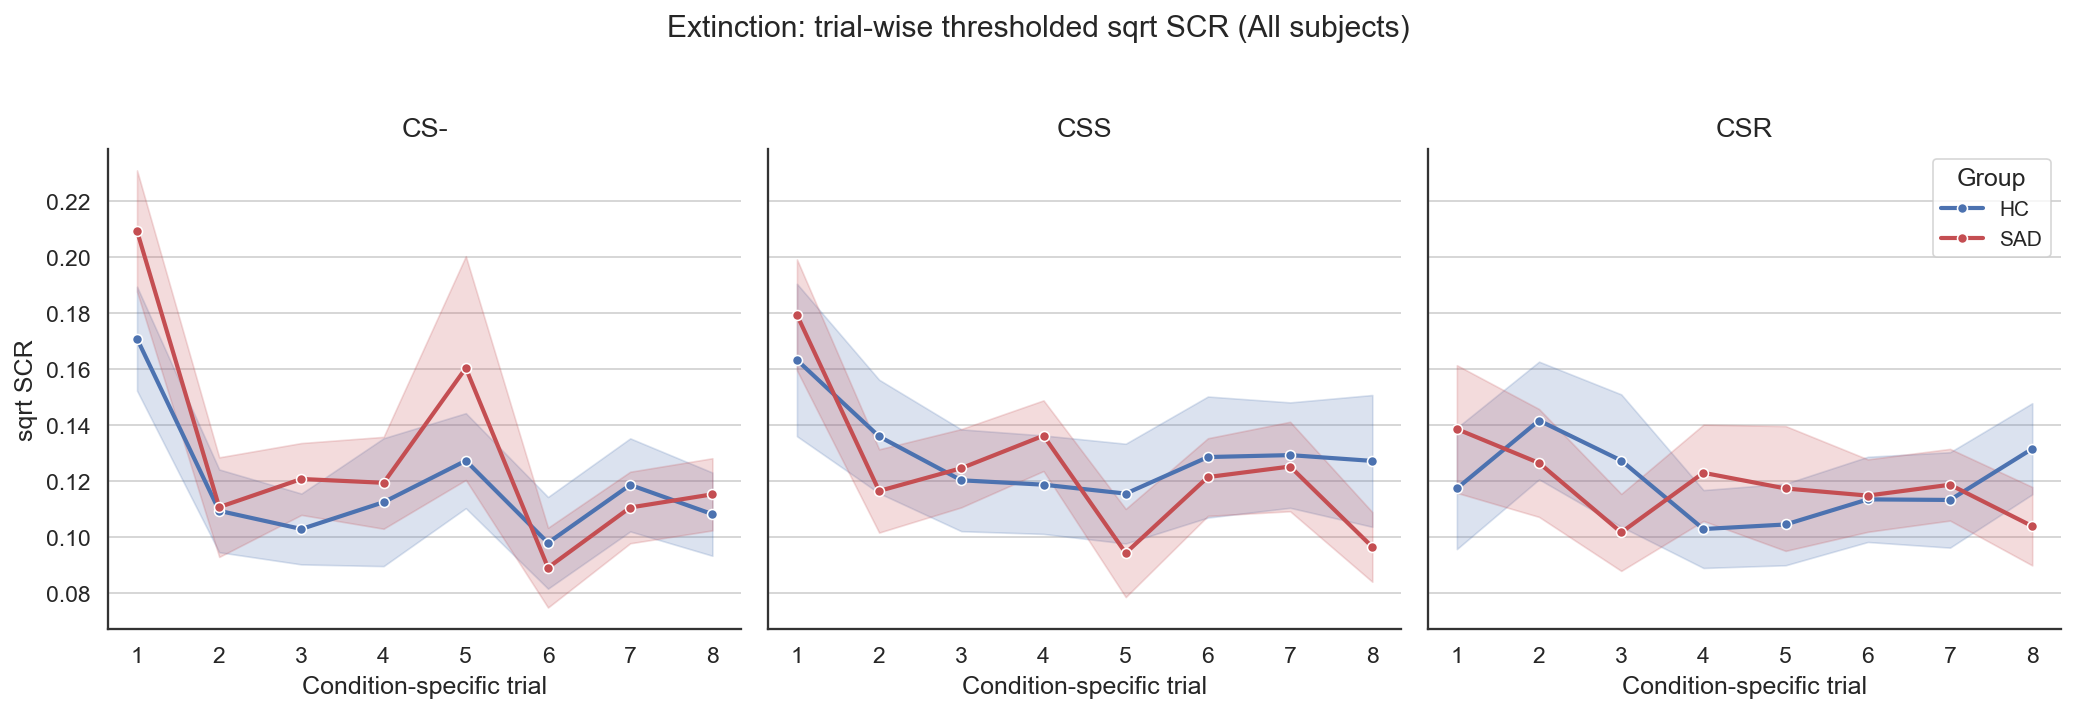

Saved figure -> scr_analysis_outputs/figures/scr_extinction_early_group_contrasts_all_subjects.png


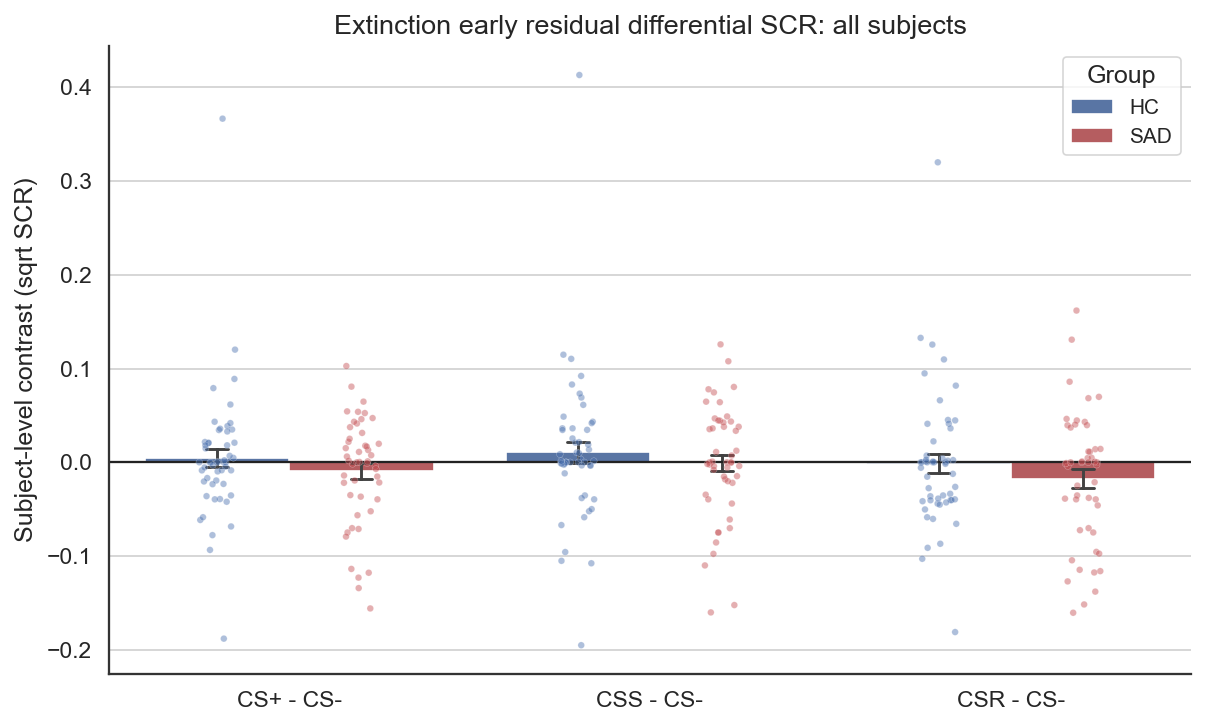

Saved figure -> scr_analysis_outputs/figures/scr_extinction_reduction_group_comparison_all_subjects.png


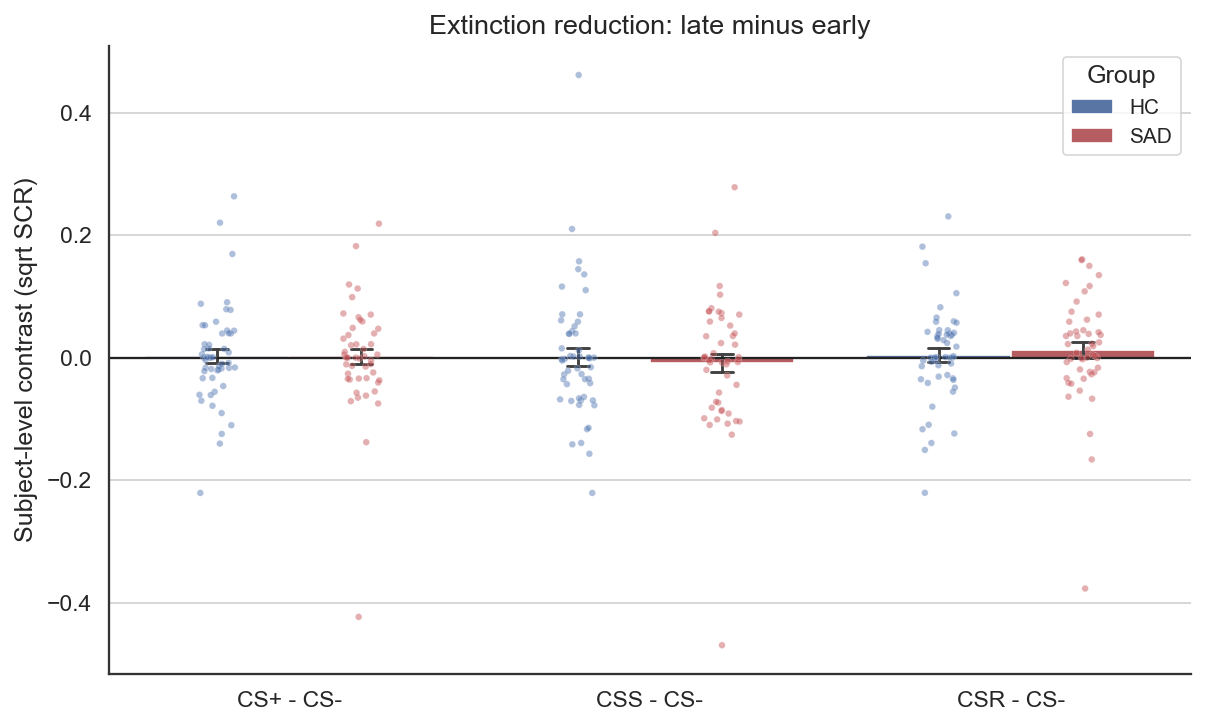

Saved figure -> scr_analysis_outputs/figures/scr_extinction_reduction_physiological_responders.png


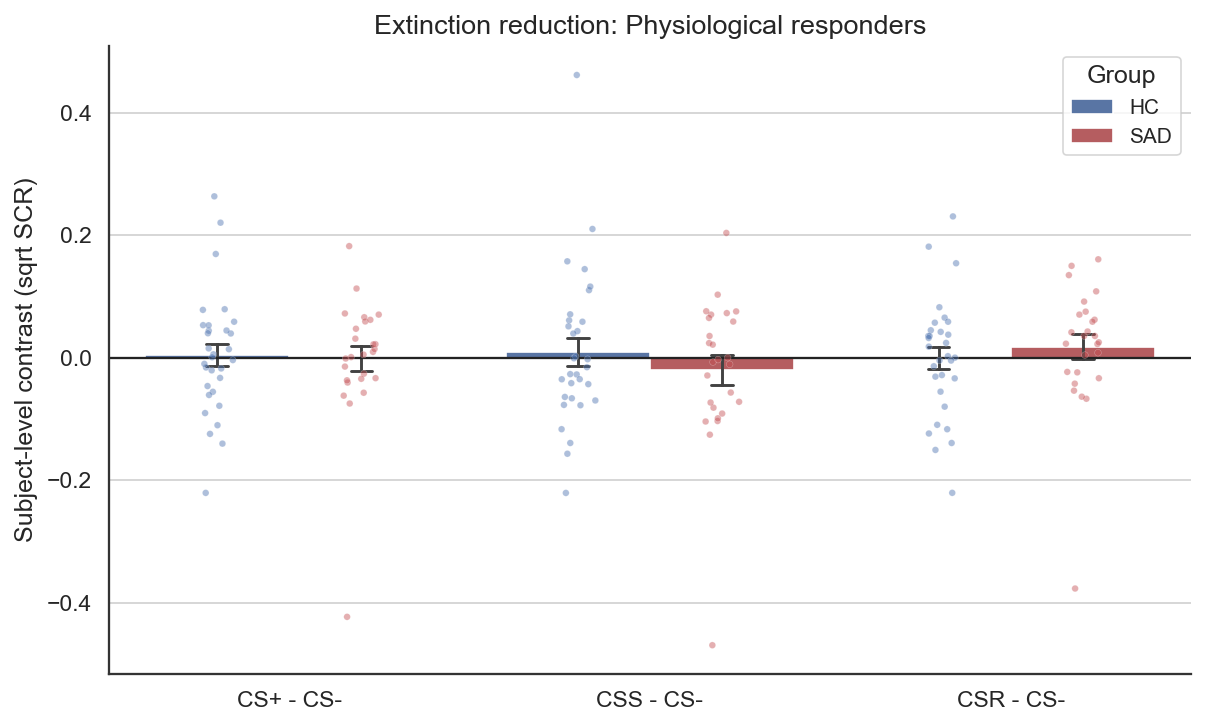

Saved figure -> scr_analysis_outputs/figures/scr_extinction_reduction_simple_csplus_learners.png


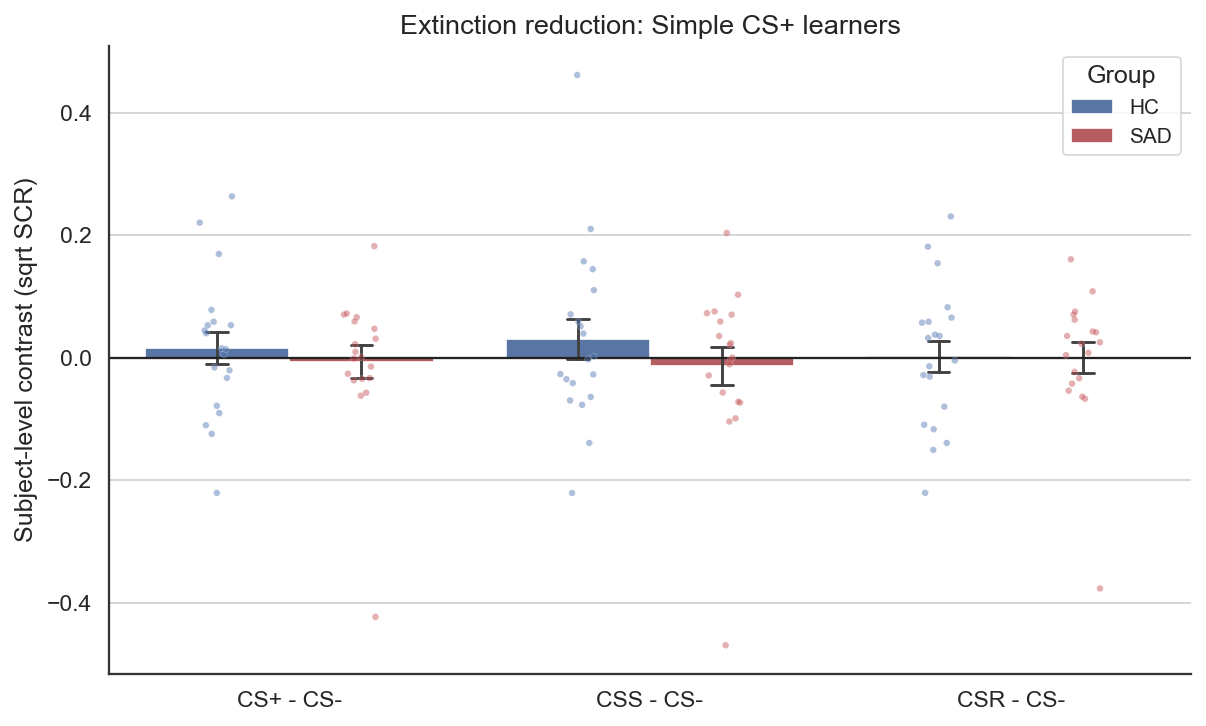

Saved figure -> scr_analysis_outputs/figures/scr_extinction_reduction_habituationadjusted_csplus_learners.png


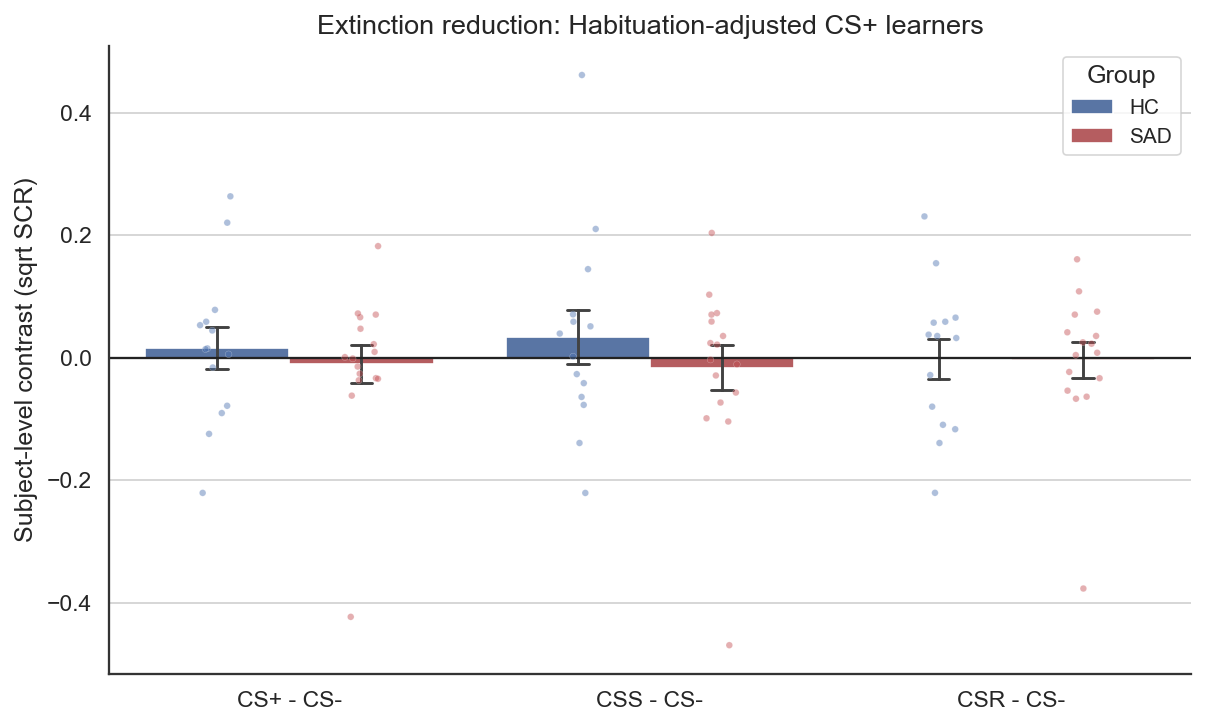

Saved figure -> scr_analysis_outputs/figures/scr_extinction_reduction_latephase_sensitivity_csplus_learners.png


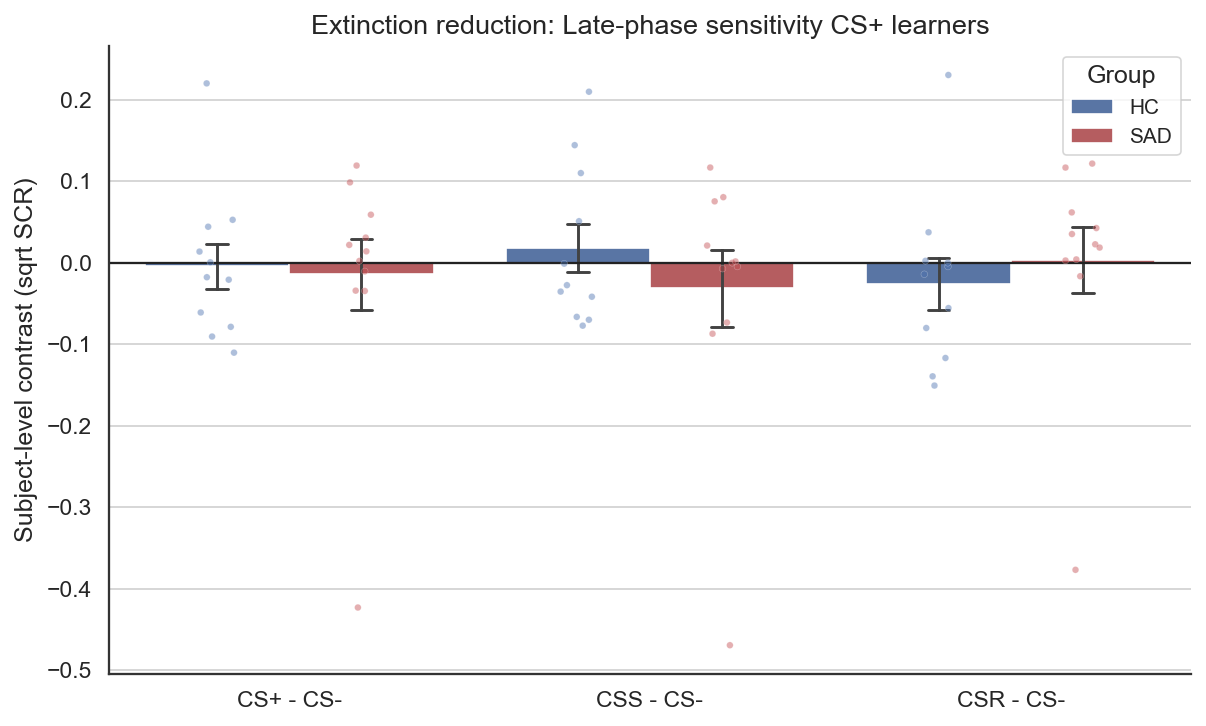

In [7]:
ext_scores, ext_stats = phase_effect_tables(all_scr, "Extinction", analysis_sets, windows=("All", "Early", "Late"), alternative="greater")
ext_change_scores, ext_change_stats = window_change_tables(all_scr, "Extinction", analysis_sets, alternative="less")
print("Extinction condition-contrast statistics")
display(ext_stats)
print("Extinction late-minus-early reduction statistics")
display(ext_change_stats)
plot_trialwise_by_group(all_scr, "Extinction", "All subjects", analysis_sets["All subjects"], "scr_extinction_trialwise_by_group_all_subjects.png")
plot_group_contrast_bars(ext_scores[ext_scores["Window"] == "Early"], ext_stats[ext_stats["Effect"].str.contains("Early")], "All subjects", "Extinction early residual differential SCR: all subjects", "scr_extinction_early_group_contrasts_all_subjects.png")
plot_group_contrast_bars(ext_change_scores, ext_change_stats, "All subjects", "Extinction reduction: late minus early", "scr_extinction_reduction_group_comparison_all_subjects.png")
for set_name in ["Physiological responders", "Simple CS+ learners", "Habituation-adjusted CS+ learners", "Late-phase sensitivity CS+ learners"]:
    plot_group_contrast_bars(ext_change_scores, ext_change_stats, set_name, f"Extinction reduction: {set_name}", f"scr_extinction_reduction_{set_name.lower().replace(' ', '_').replace('+', 'plus').replace('-', '')}.png")


## 8. Reinstatement: Return Of Fear-Conditioned Responding


Reinstatement condition-contrast statistics


,AnalysisSet,Effect,Contrast,Test,Group,N,Mean,SE,t,p,Cohen_d
0,All subjects,Reinstatement: All condition contrast,CS+ - CS-,HC vs 0,HC,52,0.010282,0.005925,1.735356,0.044359,0.240651
1,All subjects,Reinstatement: All condition contrast,CS+ - CS-,SAD vs 0,SAD,49,0.016224,0.006771,2.396144,0.010257,0.342306
2,All subjects,Reinstatement: All condition contrast,CS+ - CS-,SAD vs HC,SAD-HC,101,0.005941,NaN,0.660373,0.510589,0.131885
3,All subjects,Reinstatement: All condition contrast,CSS - CS-,HC vs 0,HC,52,0.011416,0.006308,1.809818,0.038109,0.250977
4,All subjects,Reinstatement: All condition contrast,CSS - CS-,SAD vs 0,SAD,49,0.011593,0.008119,1.427884,0.079900,0.203983
5,All subjects,Reinstatement: All condition contrast,CSS - CS-,SAD vs HC,SAD-HC,101,0.000178,NaN,0.017268,0.986260,0.003461
6,All subjects,Reinstatement: All condition contrast,CSR - CS-,HC vs 0,HC,52,0.009149,0.007389,1.238182,0.110659,0.171705
7,All subjects,Reinstatement: All condition contrast,CSR - CS-,SAD vs 0,SAD,49,0.020854,0.007791,2.676794,0.005071,0.382399
8,All subjects,Reinstatement: All condition contrast,CSR - CS-,SAD vs HC,SAD-HC,101,0.011705,NaN,1.090180,0.278299,0.217201
9,All subjects,Reinstatement: Early condition contrast,CS+ - CS-,HC vs 0,HC,52,0.010174,0.009963,1.021184,0.155993,0.141613


Reinstatement late-minus-early change statistics


,AnalysisSet,Effect,Contrast,Test,Group,N,Mean,SE,t,p,Cohen_d
0,All subjects,Reinstatement: late minus early discrimination,CS+ - CS-,HC vs 0,HC,52,0.000217,0.012812,0.016908,0.493288,0.002345
1,All subjects,Reinstatement: late minus early discrimination,CS+ - CS-,SAD vs 0,SAD,49,-0.011928,0.013548,-0.880397,0.808484,-0.125771
2,All subjects,Reinstatement: late minus early discrimination,CS+ - CS-,SAD vs HC,SAD-HC,101,-0.012144,NaN,-0.651272,0.516391,-0.129767
3,All subjects,Reinstatement: late minus early discrimination,CSS - CS-,HC vs 0,HC,52,0.002904,0.013249,0.219161,0.413700,0.030392
4,All subjects,Reinstatement: late minus early discrimination,CSS - CS-,SAD vs 0,SAD,49,-0.004726,0.016682,-0.283283,0.610911,-0.040469
5,All subjects,Reinstatement: late minus early discrimination,CSS - CS-,SAD vs HC,SAD-HC,101,-0.007629,NaN,-0.358134,0.721056,-0.071728
6,All subjects,Reinstatement: late minus early discrimination,CSR - CS-,HC vs 0,HC,52,-0.002470,0.014738,-0.167619,0.566227,-0.023245
7,All subjects,Reinstatement: late minus early discrimination,CSR - CS-,SAD vs 0,SAD,49,-0.019129,0.015365,-1.244990,0.890410,-0.177856
8,All subjects,Reinstatement: late minus early discrimination,CSR - CS-,SAD vs HC,SAD-HC,101,-0.016659,NaN,-0.782446,0.435830,-0.155837
9,Physiological responders,Reinstatement: late minus early discrimination,CS+ - CS-,HC vs 0,HC,31,0.005837,0.020836,0.280123,0.390653,0.050312


Early reinstatement return over late extinction statistics


,AnalysisSet,Effect,Contrast,Test,Group,N,Mean,SE,t,p,Cohen_d
0,All subjects,Reinstatement: early return over late extinction,CS+ - CS-,HC vs 0,HC,52,0.002764,0.012346,0.223911,0.411861,0.031051
1,All subjects,Reinstatement: early return over late extinction,CS+ - CS-,SAD vs 0,SAD,49,0.029490,0.016357,1.802908,0.038841,0.257558
2,All subjects,Reinstatement: early return over late extinction,CS+ - CS-,SAD vs HC,SAD-HC,101,0.026725,NaN,1.304105,0.195502,0.261568
3,All subjects,Reinstatement: early return over late extinction,CSS - CS-,HC vs 0,HC,52,-0.002177,0.015134,-0.143855,0.556909,-0.019949
4,All subjects,Reinstatement: early return over late extinction,CSS - CS-,SAD vs 0,SAD,49,0.023428,0.019880,1.178484,0.122206,0.168355
5,All subjects,Reinstatement: early return over late extinction,CSS - CS-,SAD vs HC,SAD-HC,101,0.025606,NaN,1.024835,0.308158,0.205505
6,All subjects,Reinstatement: early return over late extinction,CSR - CS-,HC vs 0,HC,52,0.007706,0.012602,0.611485,0.271797,0.084798
7,All subjects,Reinstatement: early return over late extinction,CSR - CS-,SAD vs 0,SAD,49,0.035551,0.016661,2.133773,0.018999,0.304825
8,All subjects,Reinstatement: early return over late extinction,CSR - CS-,SAD vs HC,SAD-HC,101,0.027845,NaN,1.332916,0.185898,0.267331
9,Physiological responders,Reinstatement: early return over late extinction,CS+ - CS-,HC vs 0,HC,31,-0.005481,0.018384,-0.298162,0.616183,-0.053551


Saved figure -> scr_analysis_outputs/figures/scr_reinstatement_trialwise_by_group_all_subjects.png


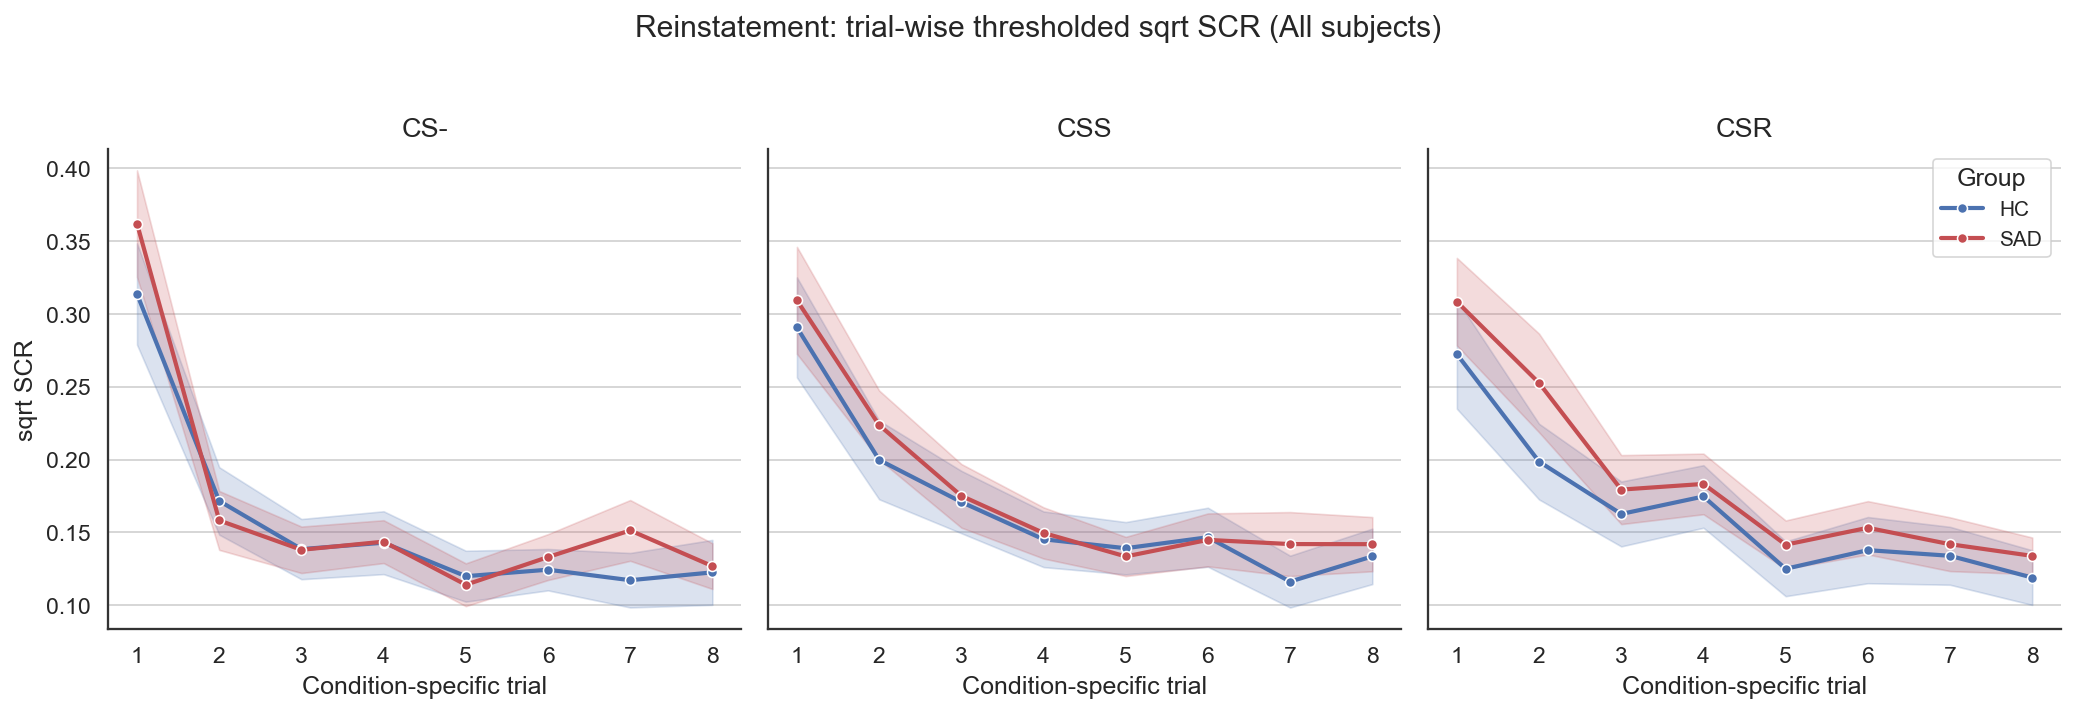

Saved figure -> scr_analysis_outputs/figures/scr_reinstatement_early_group_contrasts_all_subjects.png


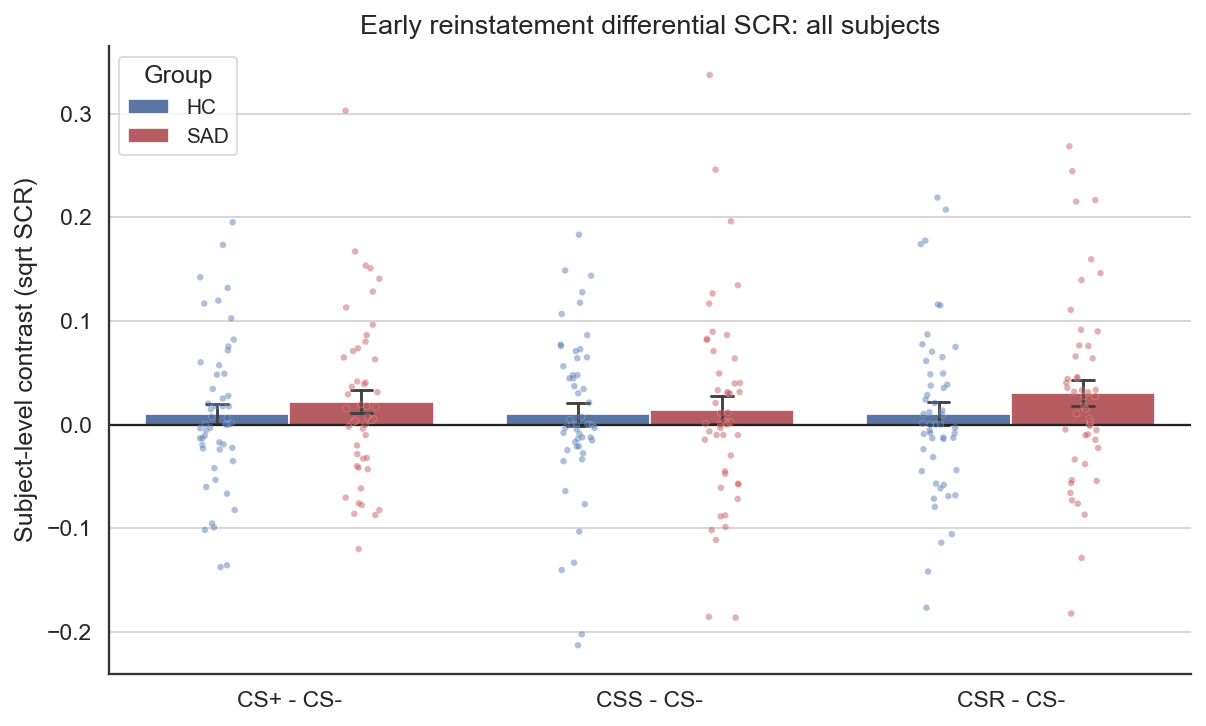

Saved figure -> scr_analysis_outputs/figures/scr_reinstatement_return_group_comparison_all_subjects.png


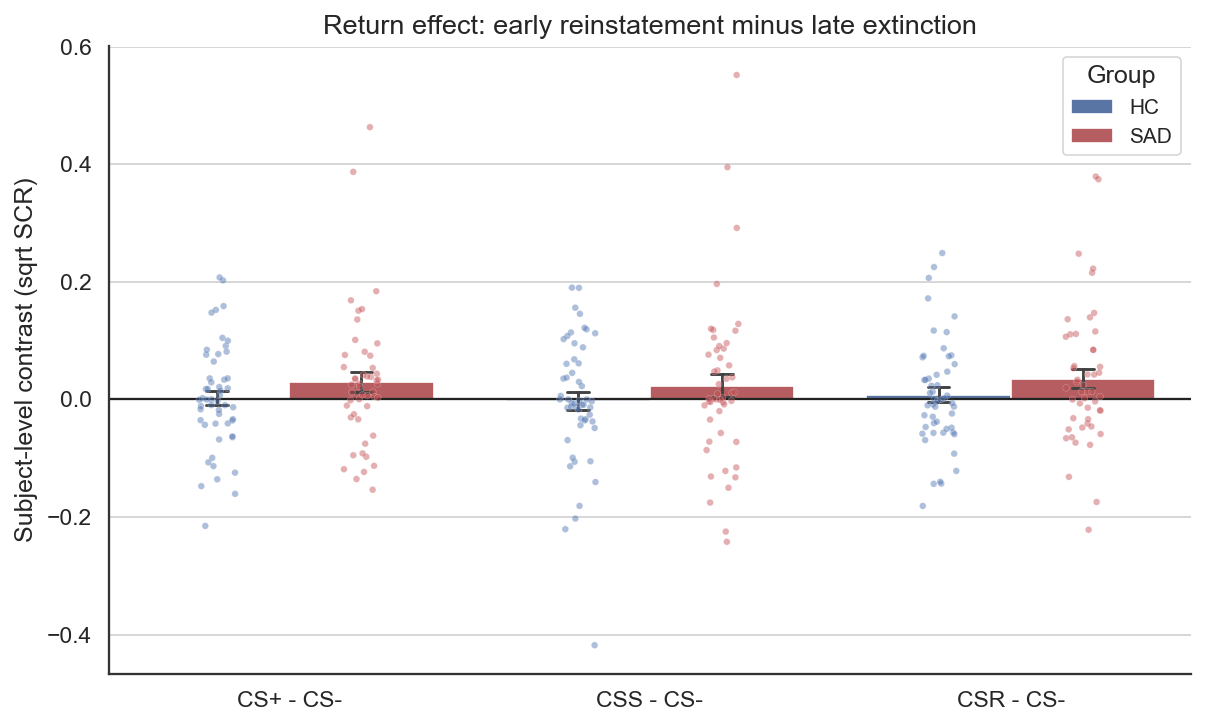

Saved figure -> scr_analysis_outputs/figures/scr_reinstatement_return_physiological_responders.png


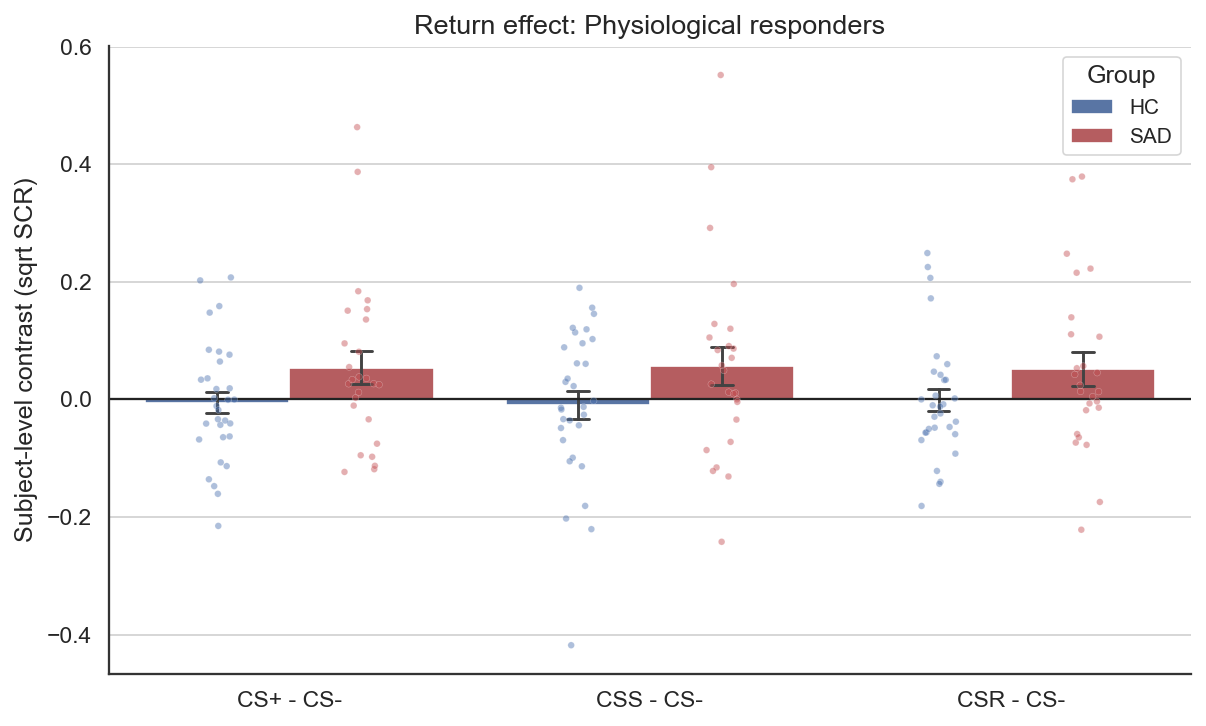

Saved figure -> scr_analysis_outputs/figures/scr_reinstatement_return_simple_csplus_learners.png


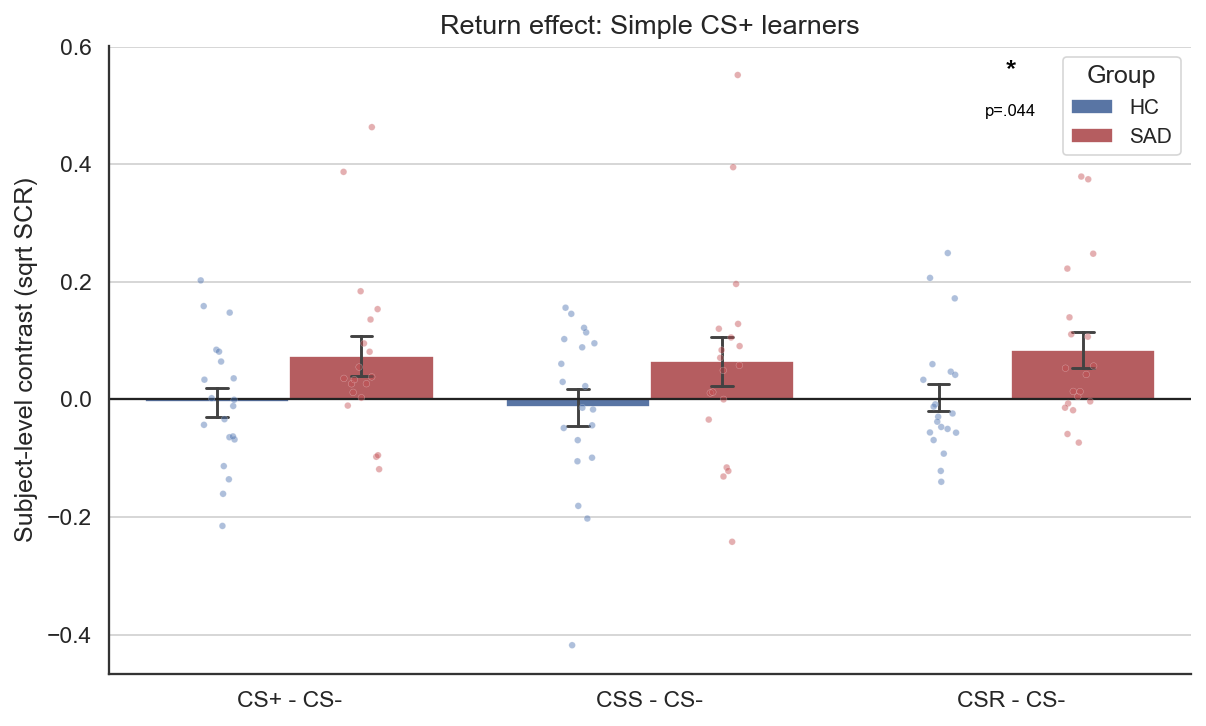

Saved figure -> scr_analysis_outputs/figures/scr_reinstatement_return_habituationadjusted_csplus_learners.png


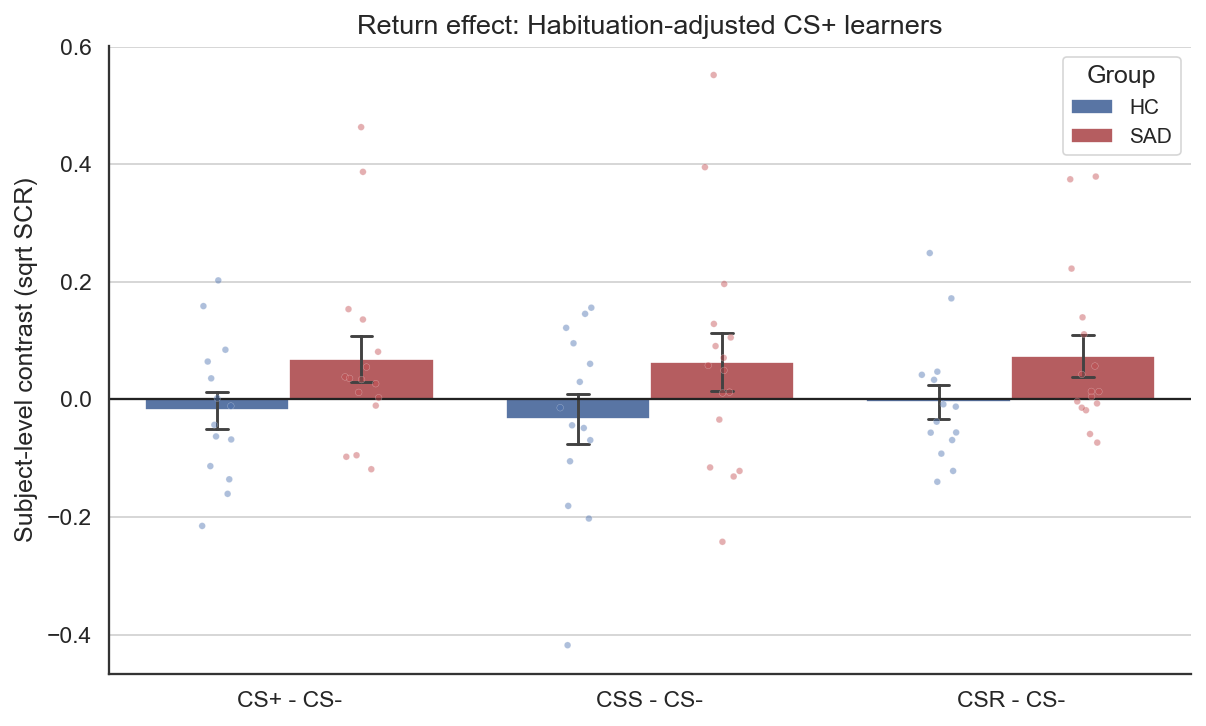

Saved figure -> scr_analysis_outputs/figures/scr_reinstatement_return_latephase_sensitivity_csplus_learners.png


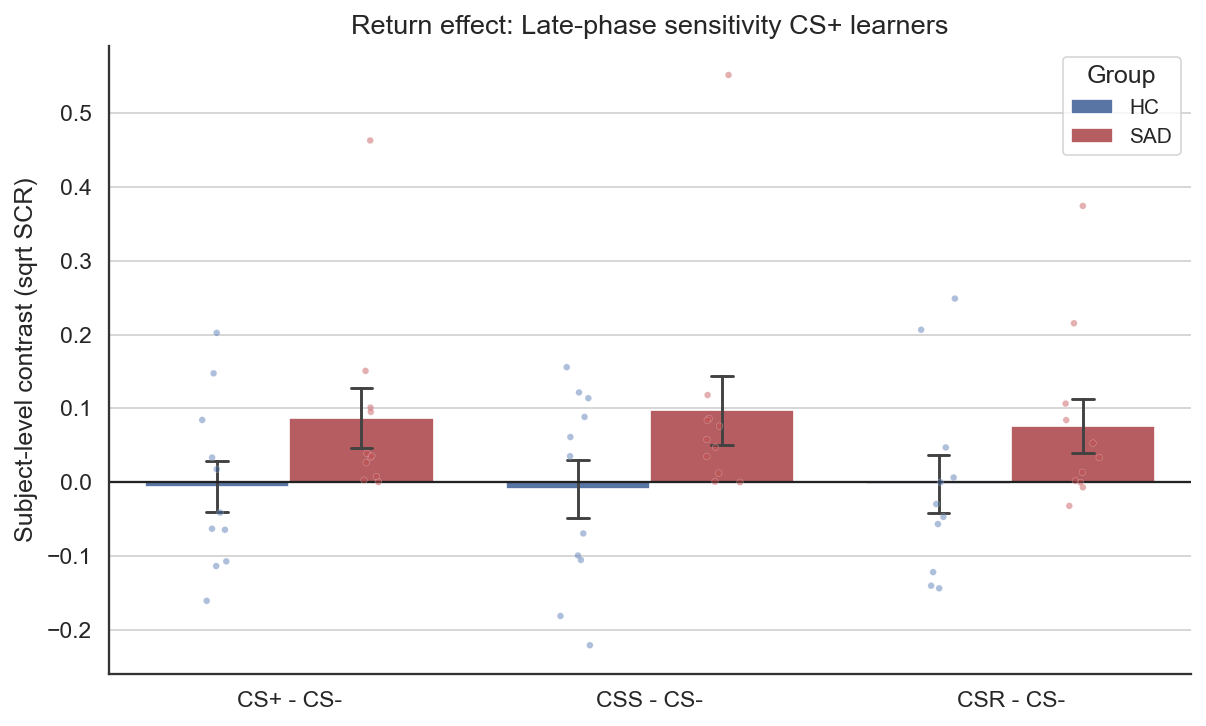

In [8]:
rein_scores, rein_stats = phase_effect_tables(all_scr, "Reinstatement", analysis_sets, windows=("All", "Early", "Late"), alternative="greater")
rein_change_scores, rein_change_stats = window_change_tables(all_scr, "Reinstatement", analysis_sets, alternative="greater")
return_scores, return_stats = reinstatement_return_tables(all_scr, analysis_sets)
print("Reinstatement condition-contrast statistics")
display(rein_stats)
print("Reinstatement late-minus-early change statistics")
display(rein_change_stats)
print("Early reinstatement return over late extinction statistics")
display(return_stats)
plot_trialwise_by_group(all_scr, "Reinstatement", "All subjects", analysis_sets["All subjects"], "scr_reinstatement_trialwise_by_group_all_subjects.png")
plot_group_contrast_bars(rein_scores[rein_scores["Window"] == "Early"], rein_stats[rein_stats["Effect"].str.contains("Early")], "All subjects", "Early reinstatement differential SCR: all subjects", "scr_reinstatement_early_group_contrasts_all_subjects.png")
plot_group_contrast_bars(return_scores, return_stats, "All subjects", "Return effect: early reinstatement minus late extinction", "scr_reinstatement_return_group_comparison_all_subjects.png")
for set_name in ["Physiological responders", "Simple CS+ learners", "Habituation-adjusted CS+ learners", "Late-phase sensitivity CS+ learners"]:
    plot_group_contrast_bars(return_scores, return_stats, set_name, f"Return effect: {set_name}", f"scr_reinstatement_return_{set_name.lower().replace(' ', '_').replace('+', 'plus').replace('-', '')}.png")


## 9. Phase-Level Summary Across Analysis Sets


Saved figure -> scr_analysis_outputs/figures/scr_phase_level_group_summary_all_subjects.png


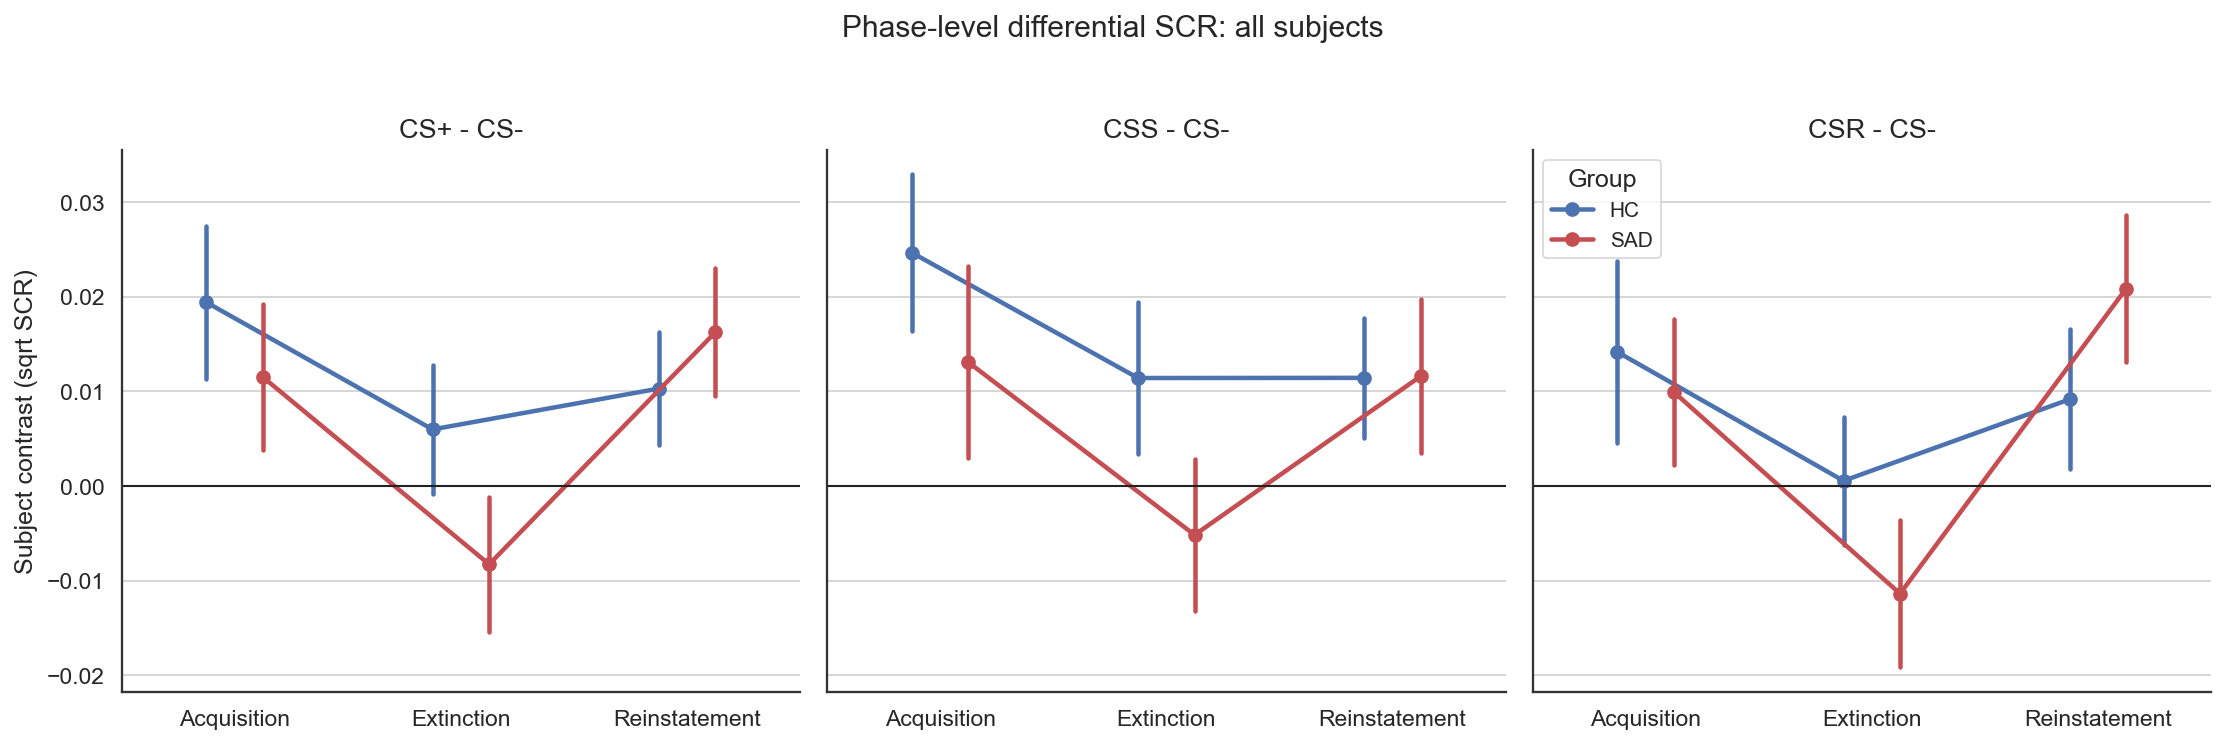

Saved figure -> scr_analysis_outputs/figures/scr_phase_level_analysis_set_summary.png


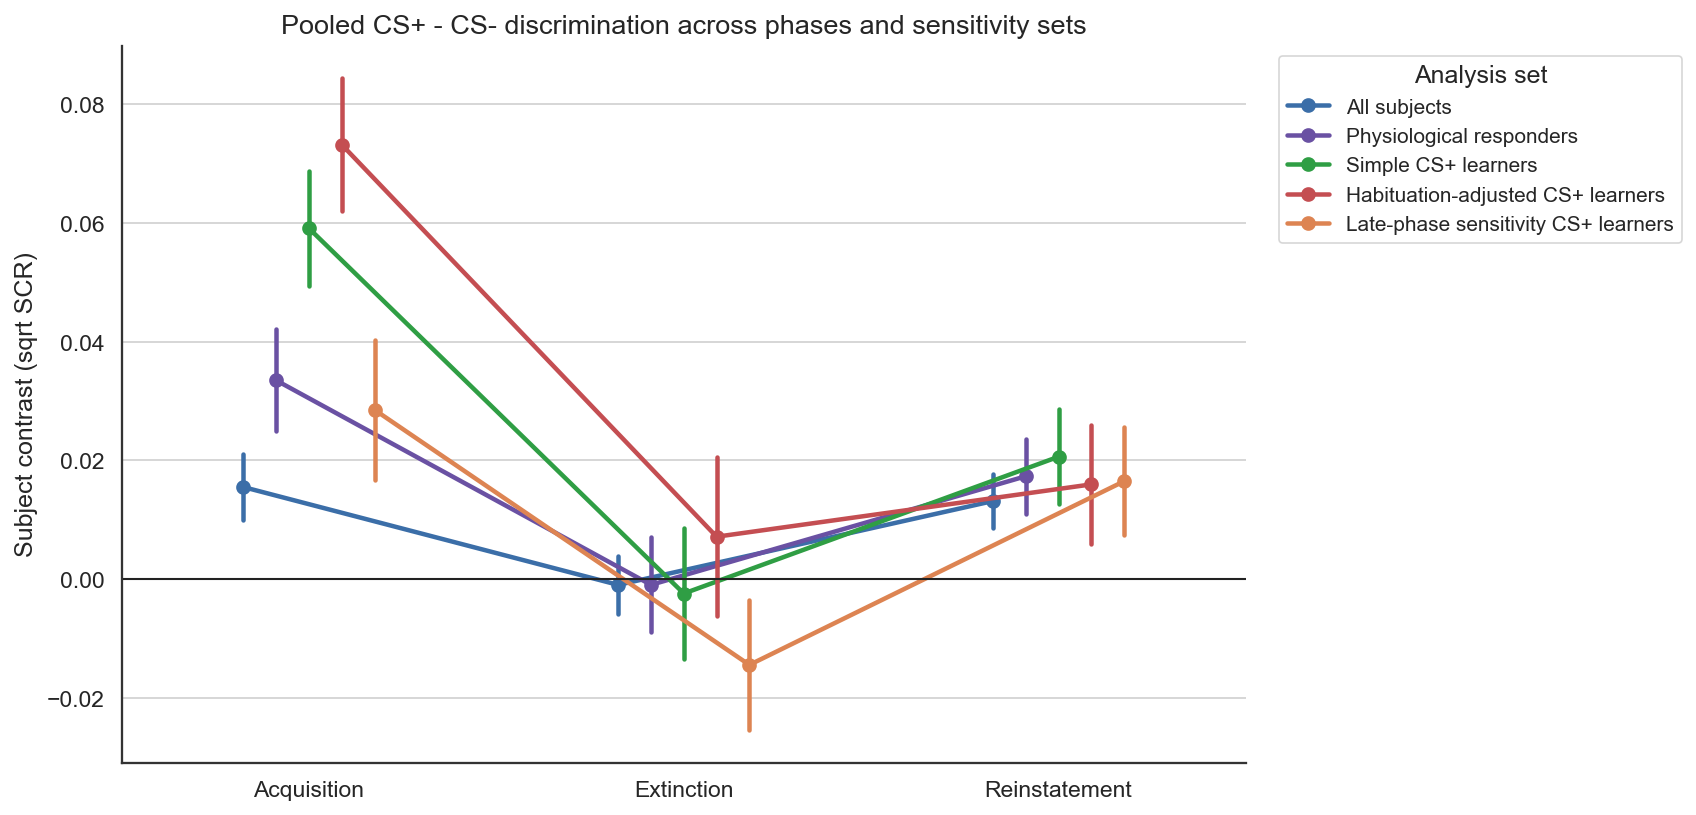

In [9]:
phase_summary_scores = []
for set_name in ANALYSIS_SET_ORDER:
    if set_name not in analysis_sets:
        continue
    subjects = analysis_sets[set_name]
    for phase in PHASE_ORDER:
        scores = subject_window_contrast_scores(all_scr, phase, subjects, window="All")
        scores["AnalysisSet"] = set_name
        phase_summary_scores.append(scores)
phase_summary_scores = pd.concat(phase_summary_scores, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, contrast in zip(axes, CONTRAST_ORDER):
    sub = phase_summary_scores[(phase_summary_scores["Contrast"] == contrast) & (phase_summary_scores["AnalysisSet"] == "All subjects")]
    sns.pointplot(data=sub, x="Phase", y="Score", hue="Group", order=PHASE_ORDER, hue_order=GROUP_ORDER, palette=GROUP_PALETTE, dodge=0.25, errorbar="se", markers="o", linestyles="-", ax=ax)
    ax.axhline(0, color="#222222", linewidth=1)
    ax.set_title(contrast)
    ax.set_xlabel("")
    ax.set_ylabel("Subject contrast (sqrt SCR)" if contrast == "CS+ - CS-" else "")
    clean_axis(ax)
    if contrast != "CSR - CS-":
        ax.legend_.remove()
fig.suptitle("Phase-level differential SCR: all subjects", y=1.03)
plt.tight_layout()
save_current_fig("scr_phase_level_group_summary_all_subjects.png")
plt.show()

fig, ax = plt.subplots(figsize=(11.5, 5.6))
sub = phase_summary_scores[phase_summary_scores["Contrast"] == "CS+ - CS-"]
sns.pointplot(data=sub, x="Phase", y="Score", hue="AnalysisSet", order=PHASE_ORDER, hue_order=ANALYSIS_SET_ORDER, palette=SET_PALETTE, dodge=0.35, errorbar="se", markers="o", linestyles="-", ax=ax)
ax.axhline(0, color="#222222", linewidth=1)
ax.set_title("Pooled CS+ - CS- discrimination across phases and sensitivity sets")
ax.set_ylabel("Subject contrast (sqrt SCR)")
ax.set_xlabel("")
clean_axis(ax)
ax.legend(title="Analysis set", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
save_current_fig("scr_phase_level_analysis_set_summary.png")
plt.show()


## 10. Save Tables


In [10]:
tables = {
    "scr_floor_summary.csv": floor_summary,
    "scr_acquisition_habituation_floor_stats.csv": habituation_stats,
    "scr_acquisition_learner_subjects.csv": learner_df,
    "scr_acquisition_learner_summary.csv": learner_summary,
    "scr_acquisition_learner_by_group.csv": learner_by_group,
    "scr_acquisition_learner_by_group_drug.csv": learner_by_group_drug,
    "scr_acquisition_scores.csv": acq_scores,
    "scr_acquisition_stats.csv": acq_stats,
    "scr_acquisition_window_change_scores.csv": acq_change_scores,
    "scr_acquisition_window_change_stats.csv": acq_change_stats,
    "scr_extinction_scores.csv": ext_scores,
    "scr_extinction_stats.csv": ext_stats,
    "scr_extinction_window_change_scores.csv": ext_change_scores,
    "scr_extinction_window_change_stats.csv": ext_change_stats,
    "scr_reinstatement_scores.csv": rein_scores,
    "scr_reinstatement_stats.csv": rein_stats,
    "scr_reinstatement_window_change_scores.csv": rein_change_scores,
    "scr_reinstatement_window_change_stats.csv": rein_change_stats,
    "scr_reinstatement_return_scores.csv": return_scores,
    "scr_reinstatement_return_stats.csv": return_stats,
    "scr_phase_summary_scores.csv": phase_summary_scores,
}
for name, table in tables.items():
    path = OUT_DIR / name
    table.to_csv(path, index=False)
    print("Saved", path)
subject_lists = {
    "physiological_responder_subjects.txt": sorted(analysis_sets["Physiological responders"]),
    "simple_CSplus_learner_subjects.txt": sorted(analysis_sets["Simple CS+ learners"]),
    "habituation_adjusted_CSplus_learner_subjects.txt": sorted(analysis_sets["Habituation-adjusted CS+ learners"]),
    "late_phase_sensitivity_CSplus_learner_subjects.txt": sorted(analysis_sets["Late-phase sensitivity CS+ learners"]),
}
for name, subjects in subject_lists.items():
    path = OUT_DIR / name
    text = "\n".join(subjects) + ("\n" if subjects else "")
    path.write_text(text)
    print("Saved", path)
print("Done. Figures are in", FIG_DIR.resolve())


Saved scr_analysis_outputs/scr_floor_summary.csv
Saved scr_analysis_outputs/scr_acquisition_habituation_floor_stats.csv
Saved scr_analysis_outputs/scr_acquisition_learner_subjects.csv
Saved scr_analysis_outputs/scr_acquisition_learner_summary.csv
Saved scr_analysis_outputs/scr_acquisition_learner_by_group.csv
Saved scr_analysis_outputs/scr_acquisition_learner_by_group_drug.csv
Saved scr_analysis_outputs/scr_acquisition_scores.csv
Saved scr_analysis_outputs/scr_acquisition_stats.csv
Saved scr_analysis_outputs/scr_acquisition_window_change_scores.csv
Saved scr_analysis_outputs/scr_acquisition_window_change_stats.csv
Saved scr_analysis_outputs/scr_extinction_scores.csv
Saved scr_analysis_outputs/scr_extinction_stats.csv
Saved scr_analysis_outputs/scr_extinction_window_change_scores.csv
Saved scr_analysis_outputs/scr_extinction_window_change_stats.csv
Saved scr_analysis_outputs/scr_reinstatement_scores.csv
Saved scr_analysis_outputs/scr_reinstatement_stats.csv
Saved scr_analysis_outputs/sc